# 1. Project Introduction

## 1.1 Business Problem
The D2C personal-care company aims to reduce customer churn without applying blanket discounts to all customers.

Before developing predictive models or retention strategies, the business must understand:

• Customer purchasing behavior
• Engagement patterns
• Customer support interactions
• Campaign effectiveness
• Early indicators of churn

This analysis focuses on auditing the available data, exploring customer behavior, and identifying evidence-based churn-risk patterns.

## 1.2 Objective
The objectives of this analysis are:

1. Assess data quality and identify potential issues.
2. Validate dataset relationships and integration feasibility.
3. Create a customer-level analytical dataset.
4. Explore customer demographics and behavior.
5. Investigate churn-related patterns.
6. Formulate data-backed churn-risk hypotheses.
7. Provide business recommendations for future retention initiatives.

## 1.3 Datasets Used
| Dataset              | Description                   |
| -------------------- | ----------------------------- |
| customers            | Customer profile information  |
| orders               | Purchase transactions         |
| support_tickets      | Customer support interactions |
| web_events_snapshot  | Customer engagement activity  |
| intervention_history | Campaign history              |
| churn_labels         | Churn target variable         |


## 1.4 Prediction Context
Prediction Target:
Customer churn within the next 60 days.

Reference Snapshot Date:
2025-09-30

Important:
Only information available on or before the snapshot date should be used for analysis and future modeling activities.

## 1.5 Analysis Roadmap
Raw Datasets
      ↓
Data Quality Audit
      ↓
Join Validation
      ↓
Customer Master Dataset
      ↓
Exploratory Analysis
      ↓
Churn Investigation
      ↓
Business Insights

# 2. Data Loading & Initial Inspection

## 2.1 Import Libraries

In [13]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from pathlib import Path
from IPython.display import display

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2.2 Load All Datasets

In [14]:
customers = pd.read_csv("../data/customers.csv")

orders = pd.read_csv(
    "../data/orders.csv",
    parse_dates=["order_date"]
)

tickets = pd.read_csv(
    "../data/support_tickets.csv"
)

web = pd.read_csv(
    "../data/web_events_snapshot.csv"
)

campaigns = pd.read_csv(
    "../data/intervention_history.csv"
)

churn = pd.read_csv(
    "../data/churn_labels.csv"
)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [15]:
from pathlib import Path

CHARTS_DIR = Path("../outputs/charts")
TABLES_DIR = Path("../outputs/tables")

CHARTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

## 2.3 Dataset Shapes

In [16]:
dataset_shapes = pd.DataFrame({
    "Dataset": [
        "Customers",
        "Orders",
        "Support Tickets",
        "Web Events",
        "Campaign History",
        "Churn Labels"
    ],
    "Rows": [
        customers.shape[0],
        orders.shape[0],
        tickets.shape[0],
        web.shape[0],
        campaigns.shape[0],
        churn.shape[0]
    ],
    "Columns": [
        customers.shape[1],
        orders.shape[1],
        tickets.shape[1],
        web.shape[1],
        campaigns.shape[1],
        churn.shape[1]
    ]
})

dataset_shapes

,Dataset,Rows,Columns
0,Customers,2400,9
1,Orders,10009,10
2,Support Tickets,1921,8
3,Web Events,2400,10
4,Campaign History,2400,5
5,Churn Labels,2400,4


### Observation

The project consists of six interconnected datasets covering customer profiles, purchase transactions, support interactions, engagement activity, campaign interventions, and churn outcomes.

## 2.4 Dataset Overview

In [17]:
dataset_overview = pd.DataFrame({
    "Dataset": [
        "customers",
        "orders",
        "support_tickets",
        "web_events_snapshot",
        "intervention_history",
        "churn_labels"
    ],
    "Description": [
        "Customer demographic and profile information",
        "Purchase transactions",
        "Customer support interactions",
        "Customer engagement activity",
        "Marketing campaign history",
        "Customer churn labels"
    ],
    "Primary Identifier": [
        "customer_id",
        "order_id",
        "ticket_id",
        "customer_id",
        "customer_id",
        "customer_id"
    ]
})

dataset_overview

,Dataset,Description,Primary Identifier
0,customers,Customer demographic and profile information,customer_id
1,orders,Purchase transactions,order_id
2,support_tickets,Customer support interactions,ticket_id
3,web_events_snapshot,Customer engagement activity,customer_id
4,intervention_history,Marketing campaign history,customer_id
5,churn_labels,Customer churn labels,customer_id


### Observation

`customer_id` serves as the common integration key across datasets, enabling the creation of a unified customer-level analytical dataset for churn analysis.

## 2.5 First Look Samples

In [18]:
print("CUSTOMERS")
display(customers.head(3))

CUSTOMERS


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes


In [19]:
print("ORDERS")
display(orders.head(3))

ORDERS


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0


In [20]:
print("SUPPORT TICKETS")
display(tickets.head(3))

SUPPORT TICKETS


,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened
0,TKT000001,CUST00001,2024-10-28,damaged_item,chat,3.9,-0.16,0
1,TKT000002,CUST00001,2025-02-03,payment_issue,chat,4.8,0.44,0
2,TKT000003,CUST00002,2025-08-30,late_delivery,chat,1.0,0.00,0


In [21]:
print("WEB EVENTS")
display(web.head(3))

WEB EVENTS


,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26


In [22]:
print("CAMPAIGN HISTORY")
display(campaigns.head(3))

CAMPAIGN HISTORY


,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high


In [23]:
print("CHURN LABELS")
display(churn.head(3))

CHURN LABELS


,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train


### Observation

Initial inspection confirms the availability of demographic, behavioral, transactional, and churn-related information required for customer-level analysis.

# 3. Schema Understanding

## 3.1 Column Review

In [24]:
datasets = {
    "customers": customers,
    "orders": orders,
    "tickets": tickets,
    "web_events": web,
    "campaigns": campaigns,
    "churn_labels": churn
}

column_summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Columns": [", ".join(df.columns) for df in datasets.values()]
})

column_summary

,Dataset,Columns
0,customers,"customer_id, signup_date, city_tier, age_group..."
1,orders,"order_id, customer_id, order_date, category, q..."
2,tickets,"ticket_id, customer_id, ticket_date, issue_typ..."
3,web_events,"customer_id, snapshot_date, sessions_30d, prod..."
4,campaigns,"customer_id, snapshot_date, last_campaign_rece..."
5,churn_labels,"customer_id, snapshot_date, churn_next_60d, split"


### Observation

The datasets contain customer profile, transactional, support, engagement, campaign, and churn-related attributes, providing a comprehensive view of customer behavior.

## 3.2 Data Types Review

In [25]:
dtype_summary = pd.concat(
    [
        pd.DataFrame({
            "Dataset": name,
            "Column": df.columns,
            "Data Type": df.dtypes.astype(str).values
        })
        for name, df in datasets.items()
    ],
    ignore_index=True
)

dtype_summary

,Dataset,Column,Data Type
0,customers,customer_id,str
1,customers,signup_date,str
2,customers,city_tier,str
3,customers,age_group,str
4,customers,acquisition_channel,str
5,customers,loyalty_tier,str
6,customers,preferred_category,str
7,customers,skin_type,str
8,customers,marketing_consent,str
9,orders,order_id,str


### Observation

Most columns have appropriate data types, although several date fields remain stored as strings and will be standardized during data preparation.

## 3.3 Primary Key Validation

In [26]:
primary_key_check = pd.DataFrame({
    "Dataset": [
        "customers",
        "orders",
        "support_tickets",
        "churn_labels"
    ],
    "Primary Key": [
        "customer_id",
        "order_id",
        "ticket_id",
        "customer_id"
    ],
    "Unique Values": [
        customers["customer_id"].nunique(),
        orders["order_id"].nunique(),
        tickets["ticket_id"].nunique(),
        churn["customer_id"].nunique()
    ],
    "Total Rows": [
        len(customers),
        len(orders),
        len(tickets),
        len(churn)
    ]
})

primary_key_check["Valid Primary Key"] = (
    primary_key_check["Unique Values"]
    ==
    primary_key_check["Total Rows"]
)

primary_key_check

,Dataset,Primary Key,Unique Values,Total Rows,Valid Primary Key
0,customers,customer_id,2400,2400,True
1,orders,order_id,10009,10009,True
2,support_tickets,ticket_id,1921,1921,True
3,churn_labels,customer_id,2400,2400,True


### Observation

All primary key columns are unique, indicating that records can be reliably identified within each dataset.

## 3.4 Foreign Key Relationships

In [27]:
foreign_key_summary = pd.DataFrame({
    "Dataset": [
        "orders",
        "support_tickets",
        "web_events",
        "campaigns",
        "churn_labels"
    ],
    "Foreign Key": [
        "customer_id",
        "customer_id",
        "customer_id",
        "customer_id",
        "customer_id"
    ]
})

foreign_key_summary

,Dataset,Foreign Key
0,orders,customer_id
1,support_tickets,customer_id
2,web_events,customer_id
3,campaigns,customer_id
4,churn_labels,customer_id


### Observation

The `customer_id` field serves as the common linkage across datasets, enabling customer-level integration and analysis.

## 3.5 Entity Relationship Overview

In [28]:
relationship_map = pd.DataFrame({
    "Parent Dataset": ["customers"] * 5,
    "Child Dataset": [
        "orders",
        "support_tickets",
        "web_events",
        "campaigns",
        "churn_labels"
    ],
    "Relationship": [
        "1 : Many",
        "1 : Many",
        "1 : 1",
        "1 : 1",
        "1 : 1"
    ]
})

relationship_map

,Parent Dataset,Child Dataset,Relationship
0,customers,orders,1 : Many
1,customers,support_tickets,1 : Many
2,customers,web_events,1 : 1
3,customers,campaigns,1 : 1
4,customers,churn_labels,1 : 1


### Observation

The customers dataset acts as the central entity, with transactional, support, engagement, campaign, and churn information linked through customer-level relationships.

### Analytical Grain

The final analytical dataset will be constructed at the customer level, where each row represents a unique customer. Transactional, support, engagement, and campaign records will be aggregated using `customer_id` before analysis.

# 4. Data Quality Audit

## 4.1 Missing Values

In [29]:
datasets = {
    "customers": customers,
    "orders": orders,
    "tickets": tickets,
    "web_events": web,
    "campaigns": campaigns,
    "churn_labels": churn
}

missing_summary = pd.concat(
    [
        pd.DataFrame({
            "Dataset": name,
            "Column": df.columns,
            "Missing Values": df.isna().sum().values,
            "Missing %": (df.isna().mean() * 100).round(2).values
        })
        for name, df in datasets.items()
    ],
    ignore_index=True
)

missing_summary = (
    missing_summary
    .query("`Missing Values` > 0")
    .sort_values("Missing %", ascending=False)
)

missing_summary

,Dataset,Column,Missing Values,Missing %
5,customers,loyalty_tier,1386,57.75
7,customers,skin_type,401,16.71
18,orders,rating,80,0.80


In [30]:
missing_summary.to_csv(
    TABLES_DIR / "missing_values_summary.csv",
    index=False
)

### Observation

Missing values are primarily concentrated in `loyalty_tier` (57.75%) and `skin_type` (16.71%), while missing ratings are minimal (0.80%). These fields will require appropriate treatment before analysis and modeling.

## 4.2 Duplicate Records

In [31]:
duplicate_summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Duplicate Rows": [
        df.duplicated().sum()
        for df in datasets.values()
    ]
})

duplicate_summary

,Dataset,Duplicate Rows
0,customers,0
1,orders,0
2,tickets,0
3,web_events,0
4,campaigns,0
5,churn_labels,0


### Observation

No exact duplicate records were identified across any dataset, indicating good record-level integrity.

In [32]:
duplicate_like_summary = pd.DataFrame({
    "Dataset": [
        "orders",
        "tickets"
    ],
    "Duplicate-like Records": [
        orders.duplicated(
            subset=["customer_id","order_date","category"]
        ).sum(),
        tickets.duplicated(
            subset=["customer_id","ticket_date","issue_type"]
        ).sum()
    ]
})

duplicate_like_summary

,Dataset,Duplicate-like Records
0,orders,26
1,tickets,0


In [33]:
duplicate_summary.to_csv(
    TABLES_DIR / "duplicate_records_summary.csv",
    index=False
)

### Observation

A small number of duplicate-like order records (26) were identified, potentially reflecting repeated purchases rather than true duplication. No duplicate-like support tickets were found.

## 4.3 Invalid Values

In [34]:
# 4.3.1 Quantity Validation
quantity_validation = pd.DataFrame({
    "Validation Rule": ["Quantity <= 0"],
    "Invalid Records": [
        (orders["quantity"] <= 0).sum()
    ]
})

quantity_validation

,Validation Rule,Invalid Records
0,Quantity <= 0,0


In [35]:
# 4.3.2 DIscount Validation
discount_validation = pd.DataFrame({
    "Validation Rule": [
        "Discount < 0",
        "Discount > 1"
    ],
    "Invalid Records": [
        (orders["discount_pct"] < 0).sum(),
        (orders["discount_pct"] > 1).sum()
    ]
})

discount_validation

,Validation Rule,Invalid Records
0,Discount < 0,0
1,Discount > 1,0


In [36]:
# 4.3.3 Rating Validation
rating_validation = pd.DataFrame({
    "Validation Rule": [
        "Rating < 1",
        "Rating > 5"
    ],
    "Invalid Records": [
        (orders["rating"] < 1).sum(),
        (orders["rating"] > 5).sum()
    ]
})

rating_validation

,Validation Rule,Invalid Records
0,Rating < 1,0
1,Rating > 5,0


In [37]:
# 4.3.4 Sentiment Validation
sentiment_validation = pd.DataFrame({
    "Validation Rule": [
        "Sentiment < -1",
        "Sentiment > 1"
    ],
    "Invalid Records": [
        (tickets["sentiment_score"] < -1).sum(),
        (tickets["sentiment_score"] > 1).sum()
    ]
})

sentiment_validation

,Validation Rule,Invalid Records
0,Sentiment < -1,0
1,Sentiment > 1,0


In [38]:
# 4.3.5 Consolidated Validation Summary
validation_summary = pd.DataFrame({
    "Check": [
        "Quantity",
        "Discount",
        "Rating",
        "Sentiment"
    ],
    "Invalid Records": [
        (orders["quantity"] <= 0).sum(),
        ((orders["discount_pct"] < 0) | (orders["discount_pct"] > 1)).sum(),
        ((orders["rating"] < 1) | (orders["rating"] > 5)).sum(),
        ((tickets["sentiment_score"] < -1) | (tickets["sentiment_score"] > 1)).sum()
    ]
})

validation_summary

,Check,Invalid Records
0,Quantity,0
1,Discount,0
2,Rating,0
3,Sentiment,0


In [39]:
validation_summary.to_csv(
    TABLES_DIR / "invalid_values_summary.csv",
    index=False
)

### Observation
No invalid values were identified in the validated fields. Order quantities, discount percentages, ratings, and sentiment scores all fall within their expected business-defined ranges.

### Business Interpretation
The absence of invalid values indicates good data integrity for key transactional and customer experience variables, reducing the need for corrective data cleaning before analysis.

## 4.4 Outlier Assessment

In [40]:
from pathlib import Path

OUTPUT_DIR = Path("../outputs/charts")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

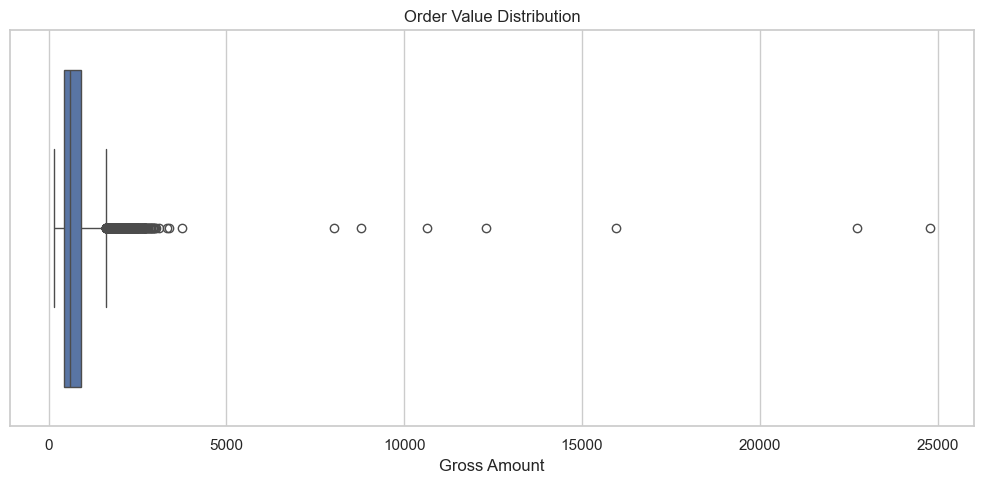

In [41]:
# 4.4.1 Order Value Distribution
plt.figure(figsize=(10,5))

sns.boxplot(
    x=orders["gross_amount"]
)

plt.title("Order Value Distribution")
plt.xlabel("Gross Amount")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "order_value_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

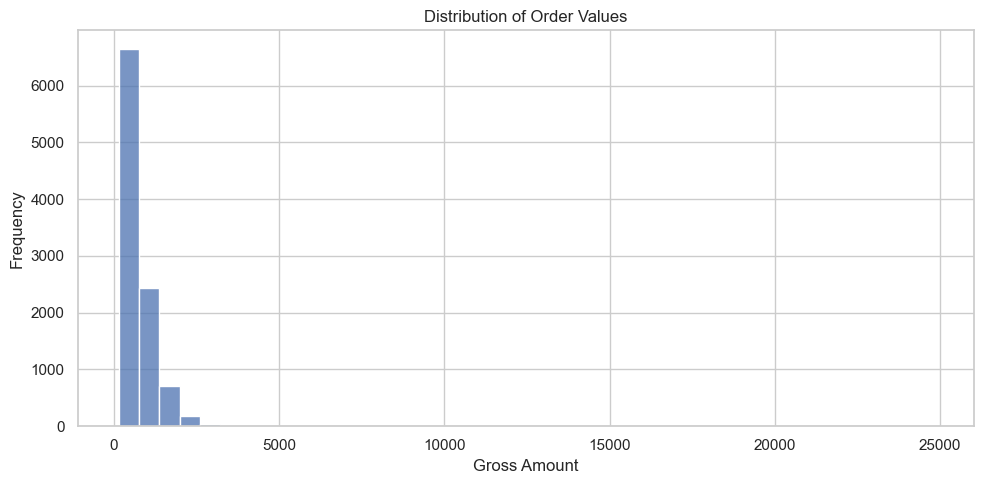

In [42]:
plt.figure(figsize=(10,5))

sns.histplot(
    orders["gross_amount"],
    bins=40)
plt.title("Distribution of Order Values")
plt.xlabel("Gross Amount")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "order_value_histogram.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

In [43]:
# 4.2.1 IQR Analysis
Q1 = orders["gross_amount"].quantile(0.25)
Q3 = orders["gross_amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = orders[
    (orders["gross_amount"] < lower_bound) |
    (orders["gross_amount"] > upper_bound)
]

outlier_summary = pd.DataFrame({
    "Metric": [
        "Q1",
        "Q3",
        "IQR",
        "Lower Bound",
        "Upper Bound",
        "Outlier Records"
    ],
    "Value": [
        round(Q1,2),
        round(Q3,2),
        round(IQR,2),
        round(lower_bound,2),
        round(upper_bound,2),
        len(outliers)
    ]
})

outlier_summary

,Metric,Value
0,Q1,432.85
1,Q3,907.43
2,IQR,474.58
3,Lower Bound,-279.02
4,Upper Bound,1619.30
5,Outlier Records,536.00


In [44]:
order_value_stats = pd.DataFrame({
    "Metric": [
        "Minimum",
        "Average",
        "Median",
        "Maximum"
    ],
    "Value": [
        round(orders["gross_amount"].min(),2),
        round(orders["gross_amount"].mean(),2),
        round(orders["gross_amount"].median(),2),
        round(orders["gross_amount"].max(),2)
    ]
})

order_value_stats

,Metric,Value
0,Minimum,149.00
1,Average,743.90
2,Median,597.06
3,Maximum,24789.38


In [45]:
# 4.4.3 Business Impact
outlier_impact = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Outlier Orders",
        "Outlier Percentage"
    ],
    "Value": [
        len(orders),
        len(outliers),
        round((len(outliers) / len(orders)) * 100, 2)
    ]
})

outlier_impact

,Metric,Value
0,Total Orders,10009.00
1,Outlier Orders,536.00
2,Outlier Percentage,5.36


In [46]:
outlier_summary.to_csv(
    TABLES_DIR / "outlier_analysis.csv",
    index=False
)

### Observation

Order values exhibit a right-skewed distribution, with 536 transactions (5.36%) identified as potential outliers. While the average order value is ₹743.90, the maximum transaction reaches ₹24,789.38, indicating the presence of a small number of exceptionally high-value purchases.
### Business Impact

These outliers are likely to represent genuine high-value customer purchases rather than data errors. They should be retained for business analysis but may require robust scaling or transformation during future modeling to reduce their influence on statistical measures.

## 4.5 Join Integrity Validation

In [47]:
## 4.5.1 Orphan Record Check
customer_ids = set(customers["customer_id"])

join_validation = pd.DataFrame({
    "Dataset": [
        "orders",
        "support_tickets",
        "web_events",
        "campaigns",
        "churn_labels"
    ],
    "Records": [
        len(orders),
        len(tickets),
        len(web),
        len(campaigns),
        len(churn)
    ],
    "Unique Customer IDs": [
        orders["customer_id"].nunique(),
        tickets["customer_id"].nunique(),
        web["customer_id"].nunique(),
        campaigns["customer_id"].nunique(),
        churn["customer_id"].nunique()
    ],
    "Orphan Customer IDs": [
        (~orders["customer_id"].isin(customer_ids)).sum(),
        (~tickets["customer_id"].isin(customer_ids)).sum(),
        (~web["customer_id"].isin(customer_ids)).sum(),
        (~campaigns["customer_id"].isin(customer_ids)).sum(),
        (~churn["customer_id"].isin(customer_ids)).sum()
    ]
})

join_validation

,Dataset,Records,Unique Customer IDs,Orphan Customer IDs
0,orders,10009,2400,0
1,support_tickets,1921,1247,0
2,web_events,2400,2400,0
3,campaigns,2400,2400,0
4,churn_labels,2400,2400,0


### Observation

No orphan customer records were identified across any dataset, indicating strong referential integrity and reliable dataset linkage through `customer_id`.

In [48]:
#  4.5.2 Merge Feasibility Assessment

merge_feasibility = pd.DataFrame({
    "Dataset": [
        "orders",
        "support_tickets",
        "web_events",
        "campaigns",
        "churn_labels"
    ],
    "Join Key": [
        "customer_id",
        "customer_id",
        "customer_id",
        "customer_id",
        "customer_id"
    ],
    "Recommended Join": [
        "LEFT JOIN",
        "LEFT JOIN",
        "LEFT JOIN",
        "LEFT JOIN",
        "LEFT JOIN"
    ]
})

merge_feasibility

,Dataset,Join Key,Recommended Join
0,orders,customer_id,LEFT JOIN
1,support_tickets,customer_id,LEFT JOIN
2,web_events,customer_id,LEFT JOIN
3,campaigns,customer_id,LEFT JOIN
4,churn_labels,customer_id,LEFT JOIN


### Observation

All datasets can be safely integrated using `customer_id`, with a customer-level LEFT JOIN strategy preserving the complete customer base during analysis.

In [49]:
customer_coverage = pd.DataFrame({
    "Dataset": [
        "orders",
        "support_tickets",
        "web_events",
        "campaigns",
        "churn_labels"
    ],
    "Customer Coverage %": [
        round(
            orders["customer_id"].nunique() /
            customers["customer_id"].nunique() * 100,
            2
        ),
        round(
            tickets["customer_id"].nunique() /
            customers["customer_id"].nunique() * 100,
            2
        ),
        round(
            web["customer_id"].nunique() /
            customers["customer_id"].nunique() * 100,
            2
        ),
        round(
            campaigns["customer_id"].nunique() /
            customers["customer_id"].nunique() * 100,
            2
        ),
        round(
            churn["customer_id"].nunique() /
            customers["customer_id"].nunique() * 100,
            2
        )
    ]
})

customer_coverage

,Dataset,Customer Coverage %
0,orders,100.00
1,support_tickets,51.96
2,web_events,100.00
3,campaigns,100.00
4,churn_labels,100.00


In [50]:
join_validation.to_csv(
    TABLES_DIR / "join_integrity_validation.csv",
    index=False
)

### Observation

Orders, web events, campaigns, and churn labels provide complete customer coverage (100%), while support tickets cover 51.96% of customers, indicating that support interactions occur for a subset of the customer base.

### Business Interpretation

The absence of orphan records confirms that customer-level dataset integration can be performed without record loss. The lower coverage of support tickets reflects normal business behavior rather than a data quality issue, as not all customers require support interactions.

## 4.6 Date Consistency Analysis

In [51]:
# 4.6.1 Snapshot Validation
customers["signup_date"] = pd.to_datetime(customers["signup_date"])

tickets["ticket_date"] = pd.to_datetime(tickets["ticket_date"])

web["snapshot_date"] = pd.to_datetime(web["snapshot_date"])

campaigns["snapshot_date"] = pd.to_datetime(campaigns["snapshot_date"])

churn["snapshot_date"] = pd.to_datetime(churn["snapshot_date"])

In [52]:
snapshot_validation = pd.DataFrame({
    "Dataset": [
        "web_events",
        "campaigns",
        "churn_labels"
    ],
    "Minimum Snapshot Date": [
        web["snapshot_date"].min(),
        campaigns["snapshot_date"].min(),
        churn["snapshot_date"].min()
    ],
    "Maximum Snapshot Date": [
        web["snapshot_date"].max(),
        campaigns["snapshot_date"].max(),
        churn["snapshot_date"].max()
    ]
})

snapshot_validation

,Dataset,Minimum Snapshot Date,Maximum Snapshot Date
0,web_events,2025-09-30,2025-09-30
1,campaigns,2025-09-30,2025-09-30
2,churn_labels,2025-09-30,2025-09-30


In [53]:
# 4.6.2 Post- snapshot Records
snapshot_date = pd.Timestamp("2025-09-30")

In [54]:
# Orders After Snapshot
post_snapshot_orders = (
    orders["order_date"] > snapshot_date
).sum()

post_snapshot_orders

np.int64(1872)

In [55]:
# Tickets After Snapshot
post_snapshot_tickets = (
    tickets["ticket_date"] > snapshot_date
).sum()

post_snapshot_tickets

np.int64(0)

In [56]:
# Consolidate Summary
future_order_pct = round(
    (post_snapshot_orders / len(orders)) * 100,
    2
)

pd.DataFrame({
    "Metric": [
        "Post-Snapshot Orders",
        "Percentage of Total Orders"
    ],
    "Value": [
        post_snapshot_orders,
        f"{future_order_pct}%"
    ]
})

,Metric,Value
0,Post-Snapshot Orders,1872
1,Percentage of Total Orders,18.7%


In [57]:
date_range_summary = pd.DataFrame({
    "Dataset": [
        "orders",
        "support_tickets"
    ],
    "Minimum Date": [
        orders["order_date"].min(),
        tickets["ticket_date"].min()
    ],
    "Maximum Date": [
        orders["order_date"].max(),
        tickets["ticket_date"].max()
    ]
})

date_range_summary

,Dataset,Minimum Date,Maximum Date
0,orders,2024-01-09,2025-11-29
1,support_tickets,2024-01-13,2025-09-30


In [58]:
date_consistency_summary.to_csv(
    TABLES_DIR / "date_consistency_summary.csv",
    index=False
)

NameError: name 'date_consistency_summary' is not defined

### Observation

All snapshot-based datasets are consistently aligned to the reference date (2025-09-30). However, 1,872 order records occur after the snapshot date, indicating the presence of future transactional information within the raw data.
### Business Interpretation

While the data is temporally consistent overall, post-snapshot orders represent future information relative to the churn prediction reference date and must be excluded from feature engineering to prevent data leakage.

## 4.7 Leakage Risk Assessment

In [59]:
#  4.7.1 Future Orders
future_orders = pd.DataFrame({
    "Leakage Source": ["Orders After Snapshot Date"],
    "Affected Records": [post_snapshot_orders]
})

future_orders

# 4.7.2 Future Tickets
future_tickets = pd.DataFrame({
    "Leakage Source": ["Tickets After Snapshot Date"],
    "Affected Records": [post_snapshot_tickets]
})

future_tickets

# 4.7.3 Future Campaign Information
future_campaigns = pd.DataFrame({
    "Dataset": [
        "web_events",
        "campaigns",
        "churn_labels"
    ],
    "Snapshot Date": [
        web["snapshot_date"].max(),
        campaigns["snapshot_date"].max(),
        churn["snapshot_date"].max()
    ]
})

future_campaigns

,Dataset,Snapshot Date
0,web_events,2025-09-30
1,campaigns,2025-09-30
2,churn_labels,2025-09-30


In [60]:
# Leakage_summary 
leakage_summary = pd.DataFrame({
    "Feature Source": [
        "Orders",
        "Support Tickets",
        "Campaign History",
        "Web Events"
    ],
    "Leakage Risk": [
        "High",
        "Low",
        "Low",
        "Low"
    ],
    "Reason": [
        "Contains post-snapshot transactions",
        "No post-snapshot records detected",
        "Aligned to snapshot date",
        "Aligned to snapshot date"
    ]
})

leakage_summary

,Feature Source,Leakage Risk,Reason
0,Orders,High,Contains post-snapshot transactions
1,Support Tickets,Low,No post-snapshot records detected
2,Campaign History,Low,Aligned to snapshot date
3,Web Events,Low,Aligned to snapshot date


In [61]:
leakage_summary.to_csv(
    TABLES_DIR / "leakage_risk_assessment.csv",
    index=False
)

### Observation

Snapshot-based datasets are consistently aligned to the reference date (2025-09-30). The primary leakage risk originates from order data, where post-snapshot transactions are present, while support tickets, campaign history, and web activity remain temporally consistent with the snapshot period.
### Business Interpretation

Future order records should be excluded from feature creation and modeling activities to prevent data leakage. Maintaining strict snapshot-date filtering will ensure that churn analysis and future predictive models reflect information that would have been available at the time of prediction.

# 5. Customer Master Dataset Construction

## 5.1 Aggregation Strategy

The raw datasets operate at different levels of granularity. To enable customer-level analysis, transactional, support, engagement, and campaign data are aggregated using `customer_id`.

The resulting customer master dataset will contain one record per customer and serve as the foundation for exploratory analysis and churn investigation.

In [62]:
# 5.2 Order Features
snapshot_date = pd.Timestamp("2025-09-30")

orders_pre_snapshot = orders[
    orders["order_date"] <= snapshot_date
].copy()

order_features = (
    orders_pre_snapshot
    .groupby("customer_id")
    .agg(
        total_orders=("order_id", "count"),
        total_spend=("gross_amount", "sum"),
        avg_order_value=("gross_amount", "mean"),
        avg_discount_pct=("discount_pct", "mean"),
        return_rate=("returned", "mean"),
        avg_rating=("rating", "mean")
    )
    .reset_index()
)

order_features.head()

,customer_id,total_orders,total_spend,avg_order_value,avg_discount_pct,return_rate,avg_rating
0,CUST00001,6,2955.57,492.5950,0.363333,0.166667,3.333333
1,CUST00002,1,581.00,581.0000,0.230000,0.000000,4.000000
2,CUST00003,1,649.98,649.9800,0.470000,0.000000,2.000000
3,CUST00004,1,1604.04,1604.0400,0.160000,0.000000,2.000000
4,CUST00005,4,2550.91,637.7275,0.442500,0.000000,2.000000


In [63]:
order_features.to_csv(
    TABLES_DIR / "order_features.csv",
    index=False
)

In [64]:
# 5.3 Support Features
support_features = (
    tickets
    .groupby("customer_id")
    .agg(
        ticket_count=("ticket_id", "count"),
        avg_resolution_hours=("resolution_hours", "mean"),
        avg_sentiment=("sentiment_score", "mean"),
        reopen_rate=("reopened", "mean")
    )
    .reset_index()
)

support_features.head()

,customer_id,ticket_count,avg_resolution_hours,avg_sentiment,reopen_rate
0,CUST00001,2,4.35,0.14,0.0
1,CUST00002,1,1.00,0.00,0.0
2,CUST00005,1,37.70,-1.00,0.0
3,CUST00006,2,17.60,-0.68,0.5
4,CUST00008,1,6.00,0.08,0.0


In [65]:
support_features.to_csv(
    TABLES_DIR / "support_features.csv",
    index=False
)

In [66]:
# 5.4 Web Features
web_features = web.copy()

web_features.head()

,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,2025-09-30,18,95,4,1,1,3,1,9


In [67]:
# 5.5 Campaign Features
campaign_features = campaigns.copy()

campaign_features.head()

,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high
3,CUST00004,2025-09-30,free_shipping,40,high
4,CUST00005,2025-09-30,welcome_offer,18,medium


In [68]:
# 5.6 Merge Logic
customer_master = (
    customers
    .merge(order_features,
           on="customer_id",
           how="left")
    .merge(support_features,
           on="customer_id",
           how="left")
    .merge(web_features,
           on="customer_id",
           how="left")
    .merge(campaign_features,
           on="customer_id",
           how="left")
    .merge(churn,
           on="customer_id",
           how="left")
)

customer_master.shape

(2400, 35)

In [69]:
customer_master.to_csv(
    TABLES_DIR / "customer_master_dataset.csv",
    index=False
)

In [70]:
# Feature Table Schema
schema_summary = pd.DataFrame({
    "Column": customer_master.columns,
    "Data Type": customer_master.dtypes.astype(str).values
})

schema_summary

,Column,Data Type
0,customer_id,str
1,signup_date,datetime64[us]
2,city_tier,str
3,age_group,str
4,acquisition_channel,str
5,loyalty_tier,str
6,preferred_category,str
7,skin_type,str
8,marketing_consent,str
9,total_orders,int64


In [71]:
schema_summary.to_csv(
    TABLES_DIR / "customer_master_schema.csv",
    index=False
)

In [72]:
feature_summary = pd.DataFrame({
    "Metric": [
        "Customers",
        "Features"
    ],
    "Value": [
        customer_master.shape[0],
        customer_master.shape[1]
    ]
})

feature_summary

feature_summary.to_csv(
    TABLES_DIR / "customer_master_summary.csv",
    index=False
)

# 6. Exploratry Data Analysis
## 6.1 Customer Demographics

In [73]:
# Age Distribution
age_distribution = (
    customer_master["age_group"]
    .value_counts(dropna=False)
    .reset_index()
)

age_distribution.columns = [
    "Age Group",
    "Customer Count"
]

age_distribution

,Age Group,Customer Count
0,25-34,1045
1,18-24,560
2,35-44,534
3,45+,261


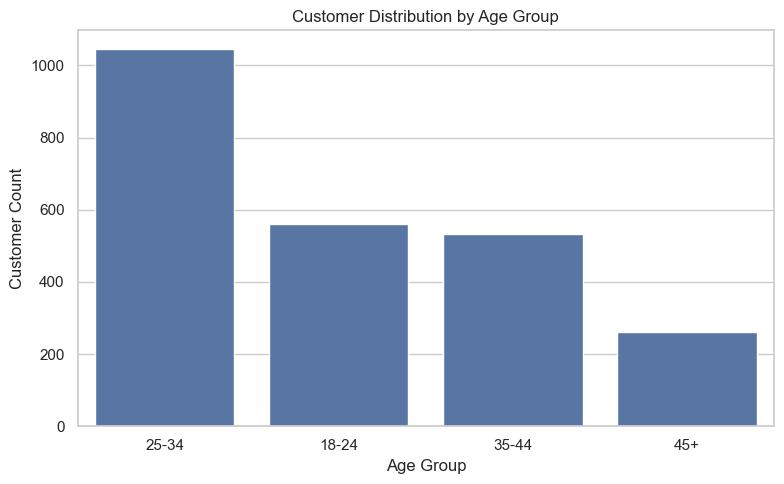

In [74]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customer_master,
    x="age_group",
    order=customer_master["age_group"].value_counts().index
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Customer Count")

plt.tight_layout()
plt.show()

In [75]:
# 6.1.2 Acquisition Channel
acquisition_distribution = (
    customer_master["acquisition_channel"]
    .value_counts(dropna=False)
    .reset_index()
)

acquisition_distribution.columns = [
    "Acquisition Channel",
    "Customer Count"
]

acquisition_distribution

,Acquisition Channel,Customer Count
0,Instagram,517
1,Google Search,466
2,Marketplace,456
3,Referral,396
4,Organic,334
5,Influencer,231


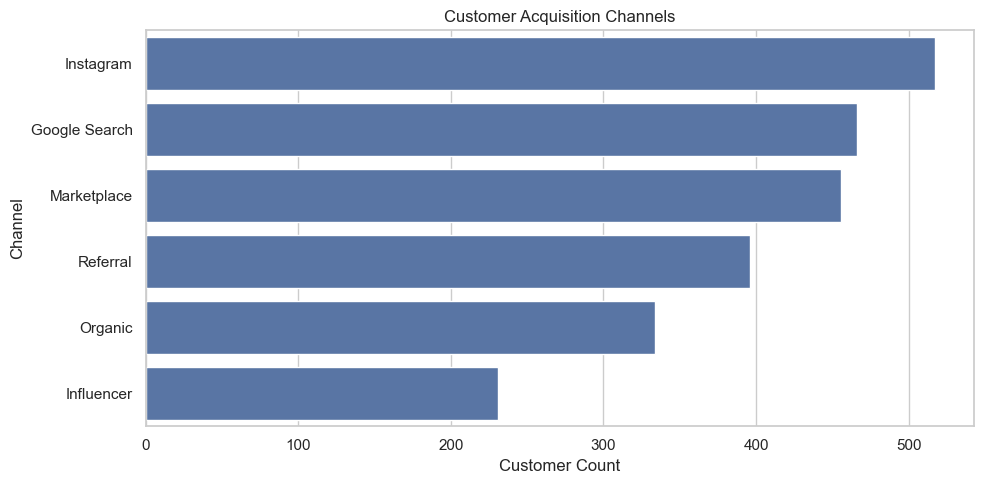

In [76]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=customer_master,
    y="acquisition_channel",
    order=customer_master["acquisition_channel"]
            .value_counts()
            .index
)

plt.title("Customer Acquisition Channels")
plt.xlabel("Customer Count")
plt.ylabel("Channel")

plt.tight_layout()
plt.show()

In [77]:
# 6.1.3 City Tier
city_tier_distribution = (
    customer_master["city_tier"]
    .value_counts(dropna=False)
    .reset_index()
)

city_tier_distribution.columns = [
    "City Tier",
    "Customer Count"
]

city_tier_distribution

,City Tier,Customer Count
0,Tier 1,1005
1,Tier 2,870
2,Tier 3,525


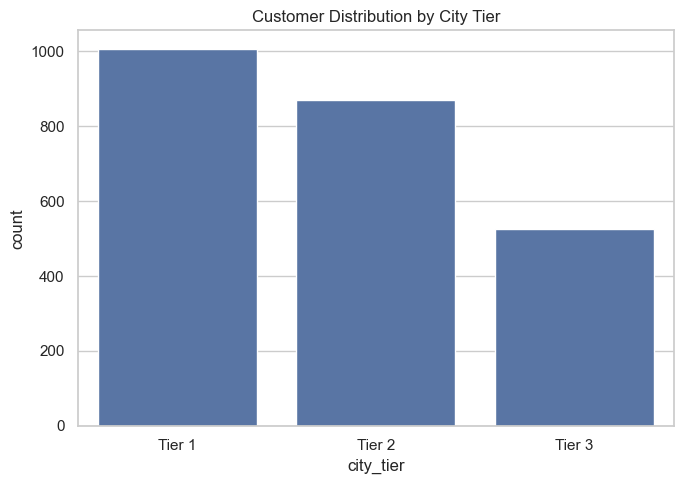

In [78]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=customer_master,
    x="city_tier",
    order=customer_master["city_tier"]
            .value_counts()
            .index
)

plt.title("Customer Distribution by City Tier")

plt.tight_layout()

plt.show()

In [79]:
# 6.1.4 Loyalty Tier
loyalty_distribution = (
    customer_master["loyalty_tier"]
    .fillna("Not Enrolled")
    .value_counts()
    .reset_index()
)

loyalty_distribution.columns = [
    "Loyalty Tier",
    "Customer Count"
]

loyalty_distribution


,Loyalty Tier,Customer Count
0,Not Enrolled,1386
1,Silver,590
2,Gold,319
3,Platinum,105


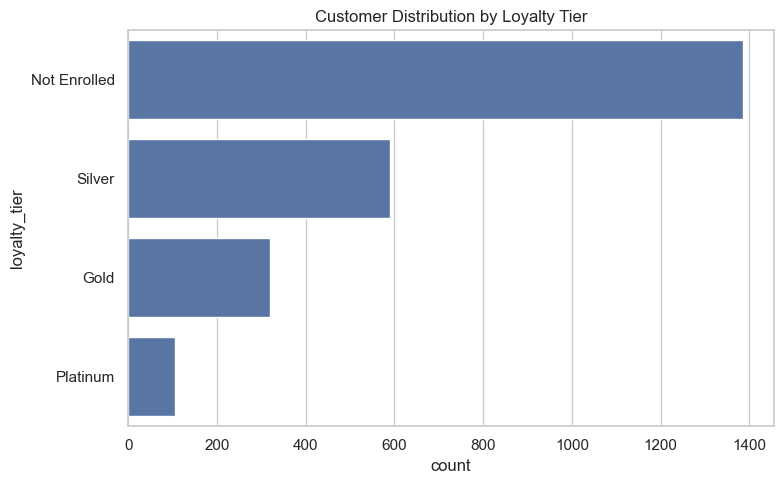

In [80]:
plt.figure(figsize=(8,5))

sns.countplot(
    y=customer_master["loyalty_tier"]
      .fillna("Not Enrolled"),
    order=customer_master["loyalty_tier"]
            .fillna("Not Enrolled")
            .value_counts()
            .index
)

plt.title("Customer Distribution by Loyalty Tier")

plt.tight_layout()

plt.show()

### Observation

The customer base is concentrated in the 25–34 age group, Tier 1 and Tier 2 cities, and digital acquisition channels such as Instagram and Google Search. More than half of customers are not enrolled in the loyalty program, indicating significant potential for membership-driven engagement initiatives.
### Business Interpretation

The customer base is predominantly composed of digitally acquired young adults. The large proportion of non-enrolled customers suggests an opportunity to strengthen retention through loyalty program adoption and targeted customer engagement strategies.

## Order Behaviour

In [81]:
# Order Count
order_count_summary = customer_master[
    ["customer_id", "total_orders"]
].copy()

order_count_summary["total_orders"].describe()

count    2400.000000
mean        3.390417
std         2.383350
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max        16.000000
Name: total_orders, dtype: float64

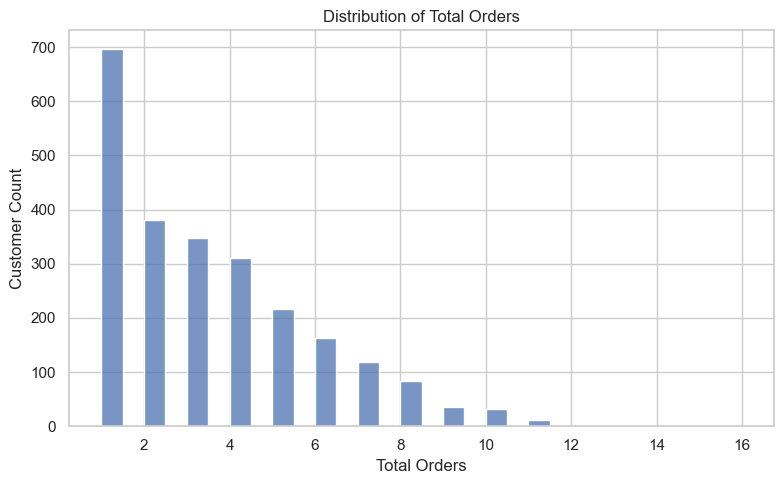

In [82]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_master["total_orders"],
    bins=30
)

plt.title("Distribution of Total Orders")
plt.xlabel("Total Orders")
plt.ylabel("Customer Count")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "order_count_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [83]:
# 6.2.2 Purchase frequency
purchase_frequency_summary = pd.DataFrame({
    "Metric": [
        "Average Orders",
        "Median Orders",
        "Maximum Orders"
    ],
    "Value": [
        round(customer_master["total_orders"].mean(), 2),
        round(customer_master["total_orders"].median(), 2),
        customer_master["total_orders"].max()
    ]
})

purchase_frequency_summary

,Metric,Value
0,Average Orders,3.39
1,Median Orders,3.00
2,Maximum Orders,16.00


In [84]:
# 6.2.3 Category Diversity

category_diversity = (
    orders_pre_snapshot
    .groupby("customer_id")
    .agg(
        category_diversity=("category", "nunique")
    )
    .reset_index()
)

customer_master = customer_master.merge(
    category_diversity,
    on="customer_id",
    how="left"
)


In [85]:
category_diversity_summary = (
    customer_master["category_diversity"]
    .describe()
)

category_diversity_summary

count    2400.000000
mean        2.351250
std         1.260371
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         6.000000
Name: category_diversity, dtype: float64

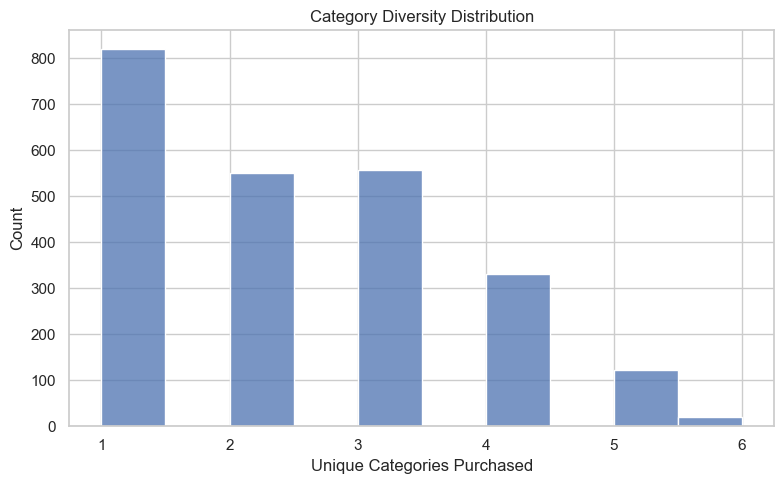

In [86]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_master["category_diversity"],
    bins=10
)

plt.title("Category Diversity Distribution")
plt.xlabel("Unique Categories Purchased")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "category_diversity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [87]:
# 6.2.4 Discount Usage
discount_usage_summary = pd.DataFrame({
    "Metric": [
        "Average Discount %",
        "Median Discount %",
        "Maximum Discount %"
    ],
    "Value": [
        round(customer_master["avg_discount_pct"].mean() * 100, 2),
        round(customer_master["avg_discount_pct"].median() * 100, 2),
        round(customer_master["avg_discount_pct"].max() * 100, 2)
    ]
})

discount_usage_summary

,Metric,Value
0,Average Discount %,28.07
1,Median Discount %,28.00
2,Maximum Discount %,64.00


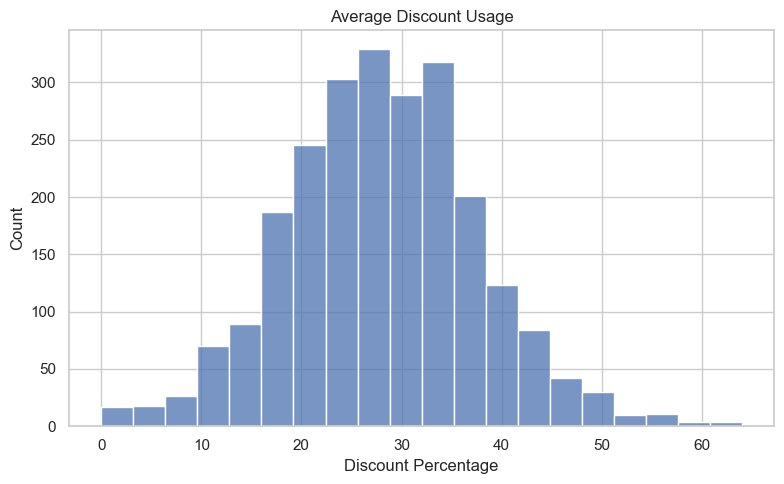

In [88]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_master["avg_discount_pct"] * 100,
    bins=20
)

plt.title("Average Discount Usage")
plt.xlabel("Discount Percentage")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "discount_usage_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Customer purchasing behavior is moderately repeat-driven, with customers placing an average of 3.39 orders and a median of 3 orders. Category diversity is relatively low (average 2.35 categories), suggesting that many customers purchase within a limited set of product categories. Discount usage is common across the customer base, with customers receiving an average discount of approximately 28%.
### Business Interpretation

The data suggests that repeat purchasing is established but category expansion opportunities remain. The widespread use of discounts indicates that promotional incentives may play an important role in customer purchasing decisions and should be further investigated as a potential churn-related factor.

## 6.3 Monetary Behaviour

In [89]:
# 6.3.1 Lifetime Revenue
revenue_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Average Revenue per Customer",
        "Median Revenue per Customer",
        "Maximum Customer Revenue"
    ],
    "Value": [
        round(customer_master["total_spend"].sum(), 2),
        round(customer_master["total_spend"].mean(), 2),
        round(customer_master["total_spend"].median(), 2),
        round(customer_master["total_spend"].max(), 2)
    ]
})

revenue_summary

,Metric,Value
0,Total Revenue,6119173.75
1,Average Revenue per Customer,2549.66
2,Median Revenue per Customer,2012.02
3,Maximum Customer Revenue,27215.92


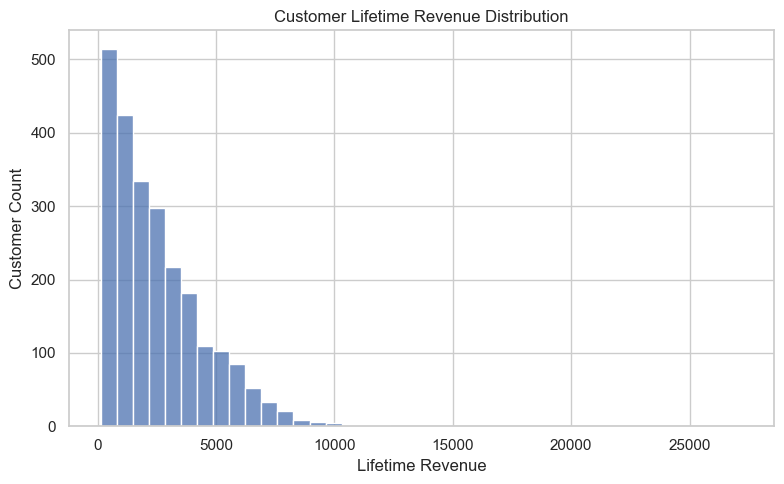

In [90]:
# 6.3.2 Revenue DIstribution

plt.figure(figsize=(8,5))

sns.histplot(
    customer_master["total_spend"],
    bins=40
)

plt.title("Customer Lifetime Revenue Distribution")
plt.xlabel("Lifetime Revenue")
plt.ylabel("Customer Count")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "lifetime_revenue_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [91]:
# 6.3.3 Average Order Value
aov_summary = pd.DataFrame({
    "Metric": [
        "Average Order Value",
        "Median Order Value",
        "Maximum Order Value"
    ],
    "Value": [
        round(customer_master["avg_order_value"].mean(), 2),
        round(customer_master["avg_order_value"].median(), 2),
        round(customer_master["avg_order_value"].max(), 2)
    ]
})

aov_summary

,Metric,Value
0,Average Order Value,753.60
1,Median Order Value,681.79
2,Maximum Order Value,8685.76


In [92]:
# 6.3.4 Revenue Concentration
customer_revenue = (
    customer_master
    .sort_values("total_spend", ascending=False)
)

top_10_pct = int(len(customer_revenue) * 0.10)

top_revenue_share = round(
    (
        customer_revenue.head(top_10_pct)["total_spend"].sum()
        /
        customer_revenue["total_spend"].sum()
    ) * 100,
    2
)

revenue_concentration = pd.DataFrame({
    "Metric": [
        "Top 10% Customers Revenue Share"
    ],
    "Value": [
        f"{top_revenue_share}%"
    ]
})

revenue_concentration

,Metric,Value
0,Top 10% Customers Revenue Share,27.64%


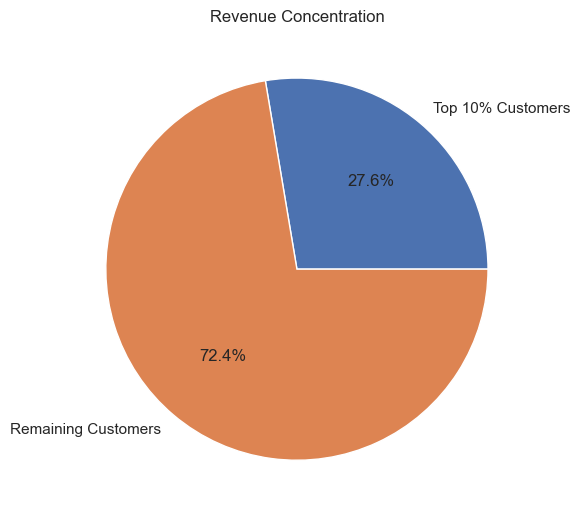

In [93]:
top_10_revenue = customer_revenue.head(top_10_pct)["total_spend"].sum()
remaining_revenue = customer_revenue.iloc[top_10_pct:]["total_spend"].sum()

revenue_share = pd.DataFrame({
    "Group": [
        "Top 10% Customers",
        "Remaining Customers"
    ],
    "Revenue": [
        top_10_revenue,
        remaining_revenue
    ]
})

plt.figure(figsize=(6,6))

plt.pie(
    revenue_share["Revenue"],
    labels=revenue_share["Group"],
    autopct="%1.1f%%"
)

plt.title("Revenue Concentration")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "revenue_concentration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [94]:
customer_master["value_segment"] = pd.qcut(
    customer_master["total_spend"],
    q=4,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "Top Value"
    ]
)

value_segment_summary = (
    customer_master["value_segment"]
    .value_counts()
    .reset_index()
)

value_segment_summary.columns = [
    "Value Segment",
    "Customer Count"
]

value_segment_summary

,Value Segment,Customer Count
0,Low Value,600
1,Medium Value,600
2,High Value,600
3,Top Value,600


### Observation

Customer spending is moderately concentrated, with total revenue of ₹6.12 million and an average customer lifetime revenue of ₹2,549.66. The top 10% of customers contribute 27.64% of total revenue, indicating the presence of a valuable high-spending customer segment. Average order values remain relatively consistent, with a median of ₹681.79 and an average of ₹753.60.
### Business Interpretation

A relatively small group of high-value customers contributes a disproportionate share of revenue, making their retention strategically important. Retention initiatives should therefore prioritize protecting high-spending customers while encouraging lower-value customers to increase purchase frequency and category adoption.

## 6.4 Support Behavior
### 6.4.1 Ticket Volume

In [95]:
ticket_volume_summary = pd.DataFrame({
    "Metric": [
        "Customers With Tickets",
        "Customers Without Tickets",
        "Average Tickets Per Customer",
        "Maximum Tickets"
    ],
    "Value": [
        customer_master["ticket_count"].notna().sum(),
        customer_master["ticket_count"].isna().sum(),
        round(customer_master["ticket_count"].fillna(0).mean(), 2),
        customer_master["ticket_count"].max()
    ]
})

ticket_volume_summary

,Metric,Value
0,Customers With Tickets,1247.0
1,Customers Without Tickets,1153.0
2,Average Tickets Per Customer,0.8
3,Maximum Tickets,6.0


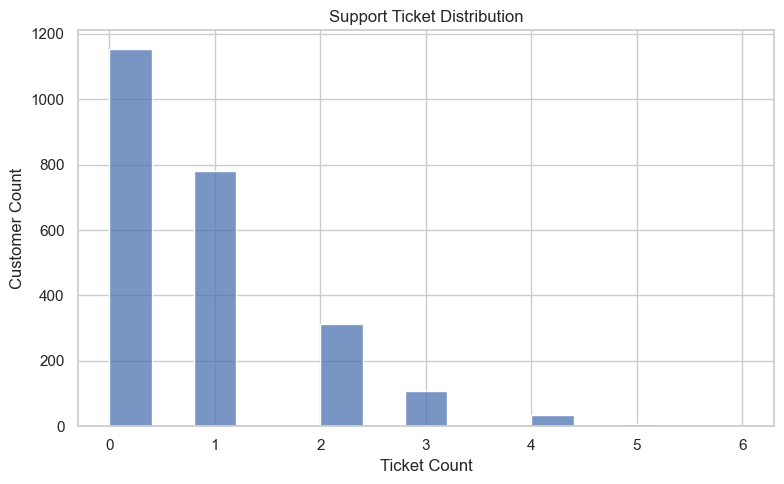

In [96]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_master["ticket_count"].fillna(0),
    bins=15
)

plt.title("Support Ticket Distribution")
plt.xlabel("Ticket Count")
plt.ylabel("Customer Count")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "ticket_volume_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [98]:
# 6.4.2 Ticket Types
ticket_type_summary = (
    tickets["issue_type"]
    .value_counts()
    .reset_index()
)

ticket_type_summary.columns = [
    "Issue Type",
    "Ticket Count"
]

ticket_type_summary

,Issue Type,Ticket Count
0,late_delivery,377
1,refund_delay,345
2,general_query,324
3,damaged_item,277
4,wrong_item,213
5,product_reaction,194
6,payment_issue,191


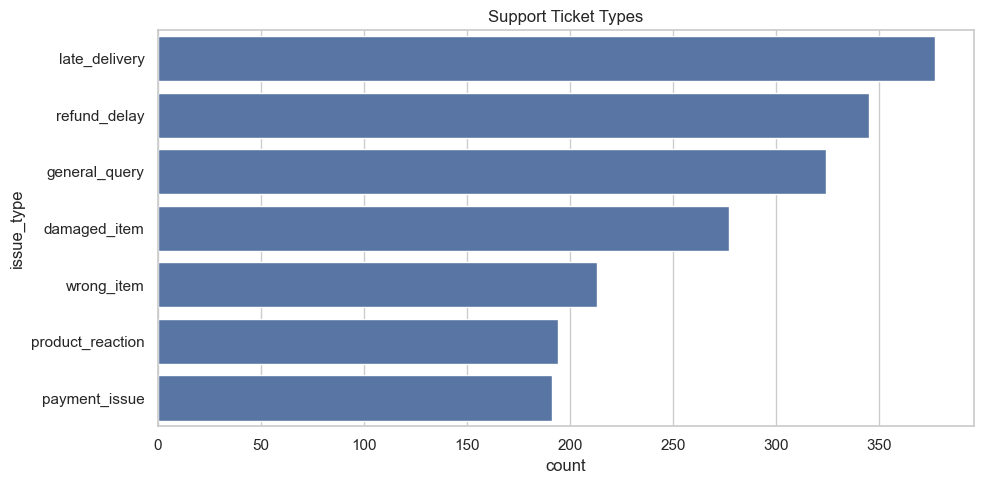

In [99]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=tickets,
    y="issue_type",
    order=tickets["issue_type"].value_counts().index
)

plt.title("Support Ticket Types")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "ticket_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [100]:
# 6.4.3 Customer Sentiment
sentiment_summary = pd.DataFrame({
    "Metric": [
        "Average Sentiment",
        "Median Sentiment",
        "Minimum Sentiment",
        "Maximum Sentiment"
    ],
    "Value": [
        round(tickets["sentiment_score"].mean(), 2),
        round(tickets["sentiment_score"].median(), 2),
        round(tickets["sentiment_score"].min(), 2),
        round(tickets["sentiment_score"].max(), 2)
    ]
})

sentiment_summary

,Metric,Value
0,Average Sentiment,-0.44
1,Median Sentiment,-0.49
2,Minimum Sentiment,-1.00
3,Maximum Sentiment,1.00


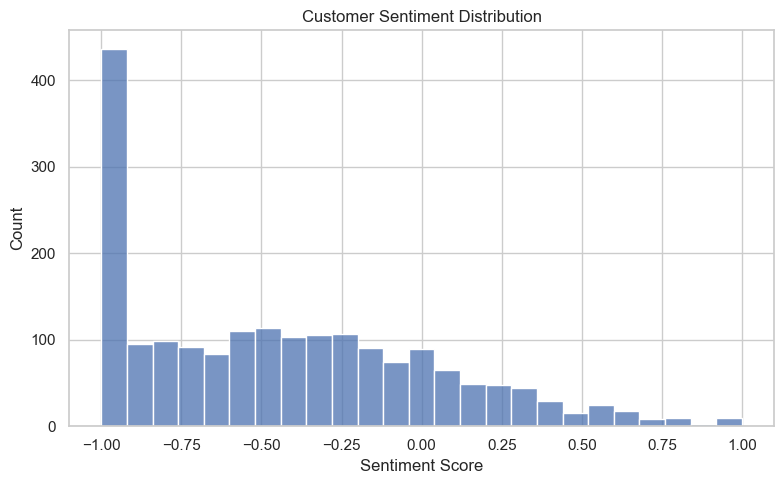

In [101]:
plt.figure(figsize=(8,5))

sns.histplot(
    tickets["sentiment_score"],
    bins=25
)

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment Score")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "customer_sentiment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Support interactions are common, with 1,247 customers (52%) raising at least one ticket. Delivery and refund-related issues are the most frequent support concerns, while overall customer sentiment is negative, with an average sentiment score of -0.44.
### Business Interpretation

Operational issues such as delivery delays and refund-related complaints appear to be major drivers of customer dissatisfaction. These factors should be investigated further as potential contributors to churn risk.

## 6.5 Return & Refund Analysis
### 6.5.1 Return Rate

In [102]:
return_summary = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Returned Orders",
        "Overall Return Rate (%)"
    ],
    "Value": [
        len(orders_pre_snapshot),
        orders_pre_snapshot["returned"].sum(),
        round(
            orders_pre_snapshot["returned"].mean() * 100,
            2
        )
    ]
})

return_summary

,Metric,Value
0,Total Orders,8137.00
1,Returned Orders,534.00
2,Overall Return Rate (%),6.56


In [103]:
# Refund Behavior
refund_issue_summary = (
    tickets["issue_type"]
    .value_counts()
    .reset_index()
)

refund_issue_summary.columns = [
    "Issue Type",
    "Count"
]

refund_issue_summary[
    refund_issue_summary["Issue Type"]
    .str.contains("refund", case=False)
]

,Issue Type,Count
1,refund_delay,345


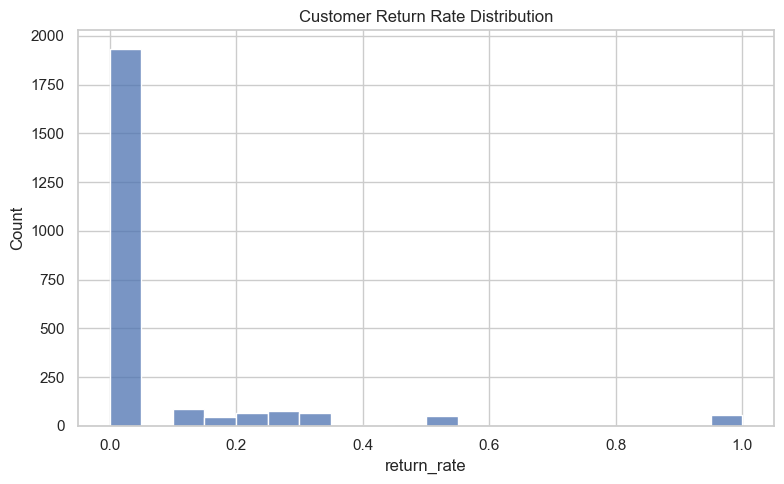

In [104]:
# 6.5.3 Dissatisfaction Signals
plt.figure(figsize=(8,5))

sns.histplot(
    customer_master["return_rate"].fillna(0),
    bins=20
)

plt.title("Customer Return Rate Distribution")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "return_rate_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The overall return rate is 6.56%, with 534 returned orders out of 8,137 transactions. Refund-related complaints are among the most common support issues, with 345 refund-delay tickets recorded.
### Business Interpretation

Although returns represent a relatively small proportion of orders, refund-related issues appear to be a significant source of customer frustration and may contribute to dissatisfaction and churn risk.

## 6.6 Web/ App Engagement
### 6.6.1 Session


In [105]:
session_summary = pd.DataFrame({
    "Metric": [
        "Average Sessions",
        "Median Sessions",
        "Maximum Sessions"
    ],
    "Value": [
        round(web["sessions_30d"].mean(),2),
        round(web["sessions_30d"].median(),2),
        web["sessions_30d"].max()
    ]
})

session_summary

,Metric,Value
0,Average Sessions,5.46
1,Median Sessions,5.00
2,Maximum Sessions,25.00


In [106]:
# 6.6.2 Days Since last Visit
visit_summary = pd.DataFrame({
    "Metric": [
        "Average Days Since Last Visit",
        "Median Days Since Last Visit",
        "Maximum Days Since Last Visit"
    ],
    "Value": [
        round(web["last_visit_days_ago"].mean(),2),
        round(web["last_visit_days_ago"].median(),2),
        web["last_visit_days_ago"].max()
    ]
})

visit_summary

,Metric,Value
0,Average Days Since Last Visit,17.65
1,Median Days Since Last Visit,14.00
2,Maximum Days Since Last Visit,60.00


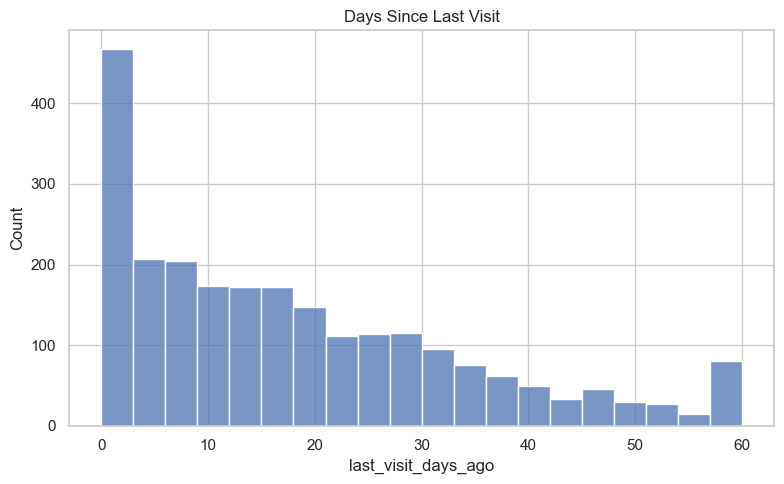

In [107]:
plt.figure(figsize=(8,5))

sns.histplot(
    web["last_visit_days_ago"],
    bins=20
)

plt.title("Days Since Last Visit")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "days_since_last_visit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [108]:
# 6.6.3 Browsing Activity
browsing_summary = pd.DataFrame({
    "Metric": [
        "Avg Product Views",
        "Avg Cart Adds",
        "Avg Wishlist Adds"
    ],
    "Value": [
        round(web["product_views_30d"].mean(),2),
        round(web["cart_adds_30d"].mean(),2),
        round(web["wishlist_adds_30d"].mean(),2)
    ]
})

browsing_summary

,Metric,Value
0,Avg Product Views,23.02
1,Avg Cart Adds,1.56
2,Avg Wishlist Adds,0.84


In [109]:
# 6.6.4 Engagement Metrics
engagement_summary = pd.DataFrame({
    "Metric": [
        "Avg Email Opens",
        "Avg Campaign Clicks",
        "Avg Abandoned Carts"
    ],
    "Value": [
        round(web["email_opens_30d"].mean(),2),
        round(web["campaign_clicks_30d"].mean(),2),
        round(web["abandoned_carts_30d"].mean(),2)
    ]
})

engagement_summary


,Metric,Value
0,Avg Email Opens,2.65
1,Avg Campaign Clicks,0.65
2,Avg Abandoned Carts,0.67


In [110]:
engagement_segments = pd.cut(
    web["sessions_30d"],
    bins=[-1, 2, 5, 10, 100],
    labels=[
        "Low Engagement",
        "Moderate Engagement",
        "High Engagement",
        "Very High Engagement"
    ]
)

engagement_segment_summary = (
    engagement_segments
    .value_counts()
    .reset_index()
)

engagement_segment_summary.columns = [
    "Engagement Segment",
    "Customer Count"
]

engagement_segment_summary

,Engagement Segment,Customer Count
0,Low Engagement,782
1,High Engagement,674
2,Moderate Engagement,599
3,Very High Engagement,345


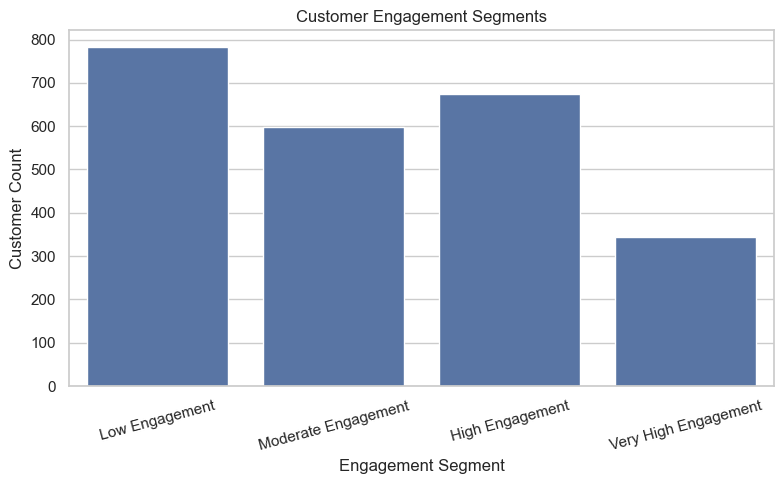

In [111]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=engagement_segments,
    order=[
        "Low Engagement",
        "Moderate Engagement",
        "High Engagement",
        "Very High Engagement"
    ]
)

plt.title("Customer Engagement Segments")
plt.xlabel("Engagement Segment")
plt.ylabel("Customer Count")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "engagement_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Customer engagement levels are moderate, with an average of 5.46 sessions and 23 product views in the last 30 days. Customers visit relatively recently on average (17.65 days since last visit), but campaign interactions remain low, with only 0.65 average clicks per customer.
### Business Interpretation

While customers continue to browse products, conversion-oriented actions such as campaign clicks, wishlist additions, and cart activity remain relatively limited. Reduced engagement and prolonged inactivity may serve as early indicators of churn risk.

## 6.7 Campaign Engagement

In [113]:
# 6.7.1 Campaign Exposer

campaign_exposure = (
    campaigns["last_campaign_received"]
    .value_counts()
    .reset_index()
)

campaign_exposure.columns = [
    "Campaign Type",
    "Customer Count"
]

campaign_exposure

,Campaign Type,Customer Count
0,none,507
1,new_launch,498
2,bundle_discount,473
3,free_shipping,469
4,welcome_offer,453


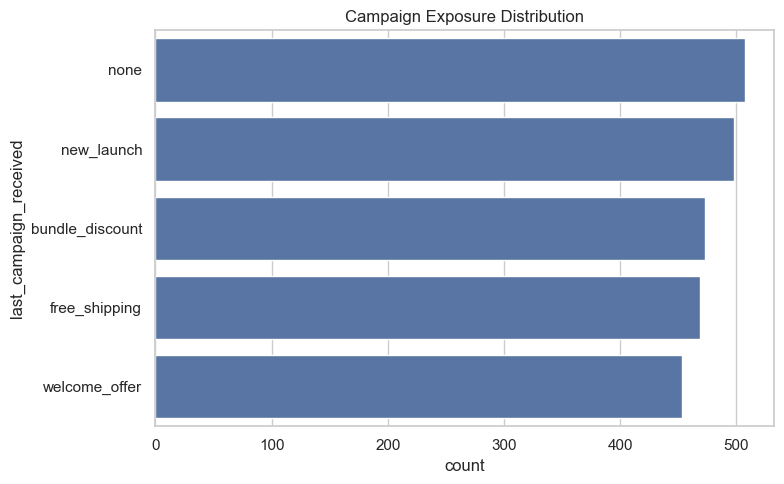

In [114]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=campaigns,
    y="last_campaign_received",
    order=campaigns["last_campaign_received"]
            .value_counts()
            .index
)

plt.title("Campaign Exposure Distribution")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "campaign_exposure_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [115]:
# 6.7.2 Campaign Clicks

In [116]:
campaign_click_summary = pd.DataFrame({
    "Metric": [
        "Average Campaign Clicks",
        "Median Campaign Clicks",
        "Maximum Campaign Clicks"
    ],
    "Value": [
        round(web["campaign_clicks_30d"].mean(), 2),
        round(web["campaign_clicks_30d"].median(), 2),
        web["campaign_clicks_30d"].max()
    ]
})

campaign_click_summary

,Metric,Value
0,Average Campaign Clicks,0.65
1,Median Campaign Clicks,0.00
2,Maximum Campaign Clicks,6.00


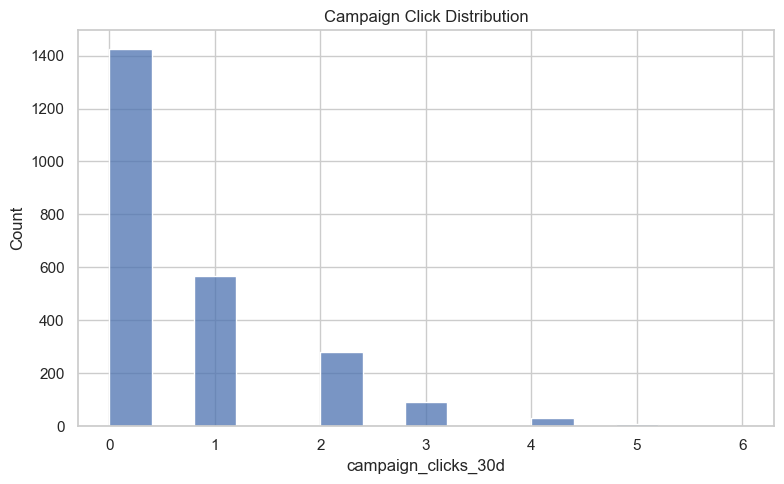

In [117]:
plt.figure(figsize=(8,5))

sns.histplot(
    web["campaign_clicks_30d"],
    bins=15
)

plt.title("Campaign Click Distribution")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "campaign_click_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [118]:
# 6.7.3 Engagement Distribution
campaign_engagement_segments = pd.cut(
    web["campaign_clicks_30d"],
    bins=[-1, 0, 2, 5, 100],
    labels=[
        "No Engagement",
        "Low Engagement",
        "Moderate Engagement",
        "High Engagement"
    ]
)

campaign_engagement_summary = (
    campaign_engagement_segments
    .value_counts()
    .reset_index()
)

campaign_engagement_summary.columns = [
    "Engagement Segment",
    "Customer Count"
]

campaign_engagement_summary

,Engagement Segment,Customer Count
0,No Engagement,1424
1,Low Engagement,848
2,Moderate Engagement,127
3,High Engagement,1


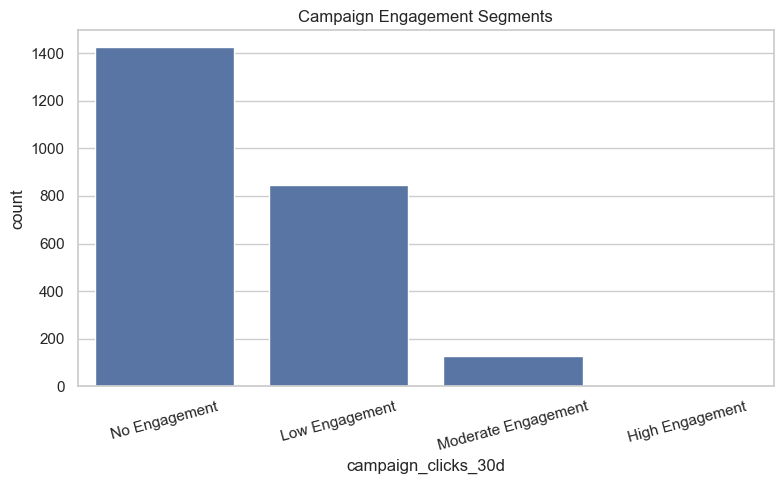

In [119]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=campaign_engagement_segments,
    order=[
        "No Engagement",
        "Low Engagement",
        "Moderate Engagement",
        "High Engagement"
    ]
)

plt.title("Campaign Engagement Segments")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "campaign_engagement_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [120]:
# Monthly Order Trend
monthly_orders = (
    orders_pre_snapshot
    .set_index("order_date")
    .resample("ME")
    .size()
    .reset_index(name="orders")
)

monthly_orders.head()

,order_date,orders
0,2024-01-31,19
1,2024-02-29,44
2,2024-03-31,109
3,2024-04-30,132
4,2024-05-31,162


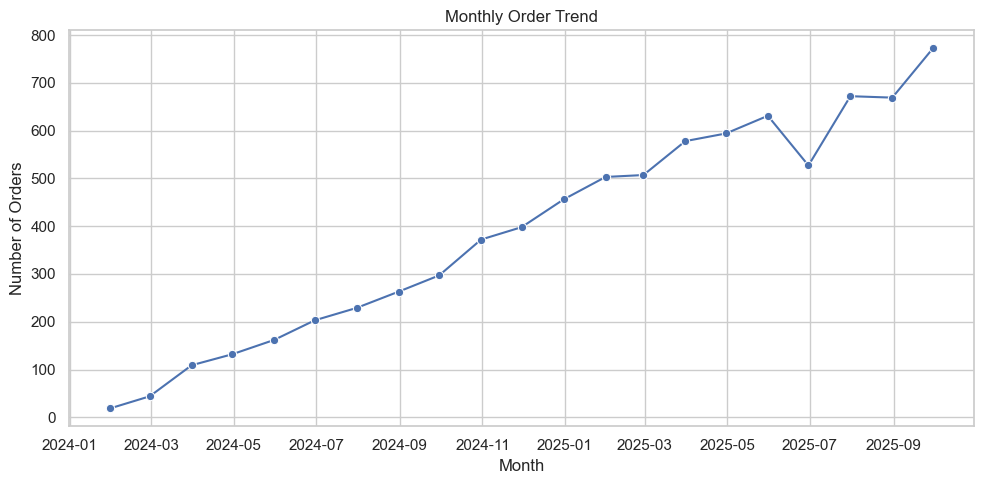

In [121]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_orders,
    x="order_date",
    y="orders",
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "monthly_order_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

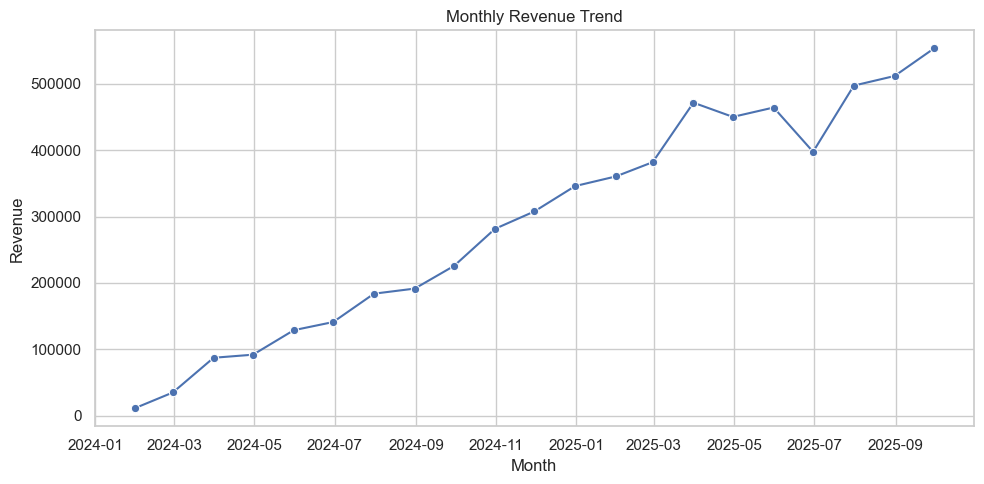

In [122]:
 # Monthly Revenue Trend
monthly_revenue = (
    orders_pre_snapshot
    .set_index("order_date")
    .resample("ME")["gross_amount"]
    .sum()
    .reset_index()
)

monthly_revenue.head()
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_revenue,
    x="order_date",
    y="gross_amount",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "monthly_revenue_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

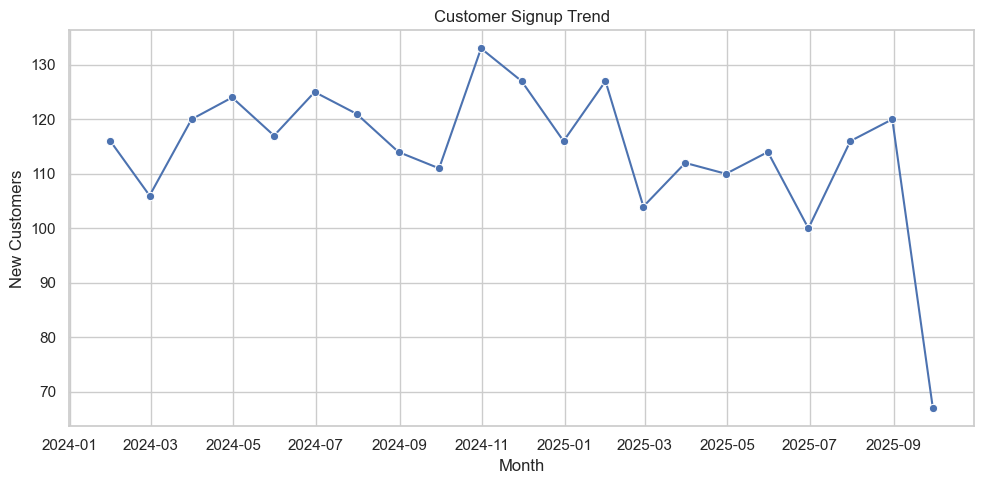

In [123]:
# Customer Signup Trend
customers["signup_date"] = pd.to_datetime(
    customers["signup_date"]
)
signup_trend = (
    customers
    .set_index("signup_date")
    .resample("ME")
    .size()
    .reset_index(name="new_customers")
)

signup_trend.head()

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=signup_trend,
    x="signup_date",
    y="new_customers",
    marker="o"
)
orders_pre_snapshot = orders_pre_snapshot.sort_values("order_date")
customers = customers.sort_values("signup_date")

plt.title("Customer Signup Trend")
plt.xlabel("Month")
plt.ylabel("New Customers")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "customer_signup_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Campaign exposure is relatively balanced across campaign types, with no single campaign dominating customer outreach. However, campaign interaction levels are low, with a median of zero clicks and nearly 59% of customers showing no campaign engagement during the observation period.
### Business Interpretation

While marketing campaigns are reaching customers, engagement remains limited. The large proportion of customers with no campaign interaction suggests an opportunity to improve campaign relevance, targeting, and personalization to strengthen customer retention efforts.

## 7 Advanced Business Analysis
### 7.1 Demographic CHurn Analysis

In [124]:
# Churn By Age
age_churn = (
    customer_master
    .groupby("age_group")["churn_next_60d"]
    .mean()
    .reset_index()
)

age_churn["churn_rate"] = (
    age_churn["churn_next_60d"] * 100
).round(2)

age_churn

,age_group,churn_next_60d,churn_rate
0,18-24,0.455357,45.54
1,25-34,0.471770,47.18
2,35-44,0.483146,48.31
3,45+,0.463602,46.36


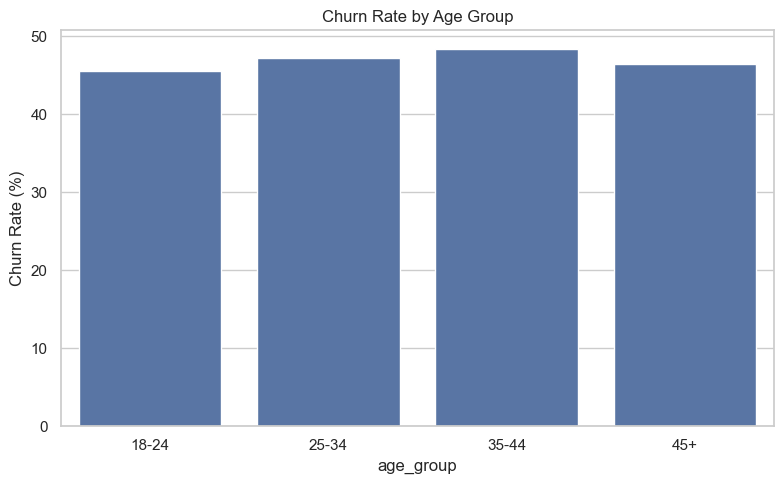

In [125]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=age_churn,
    x="age_group",
    y="churn_rate"
)

plt.title("Churn Rate by Age Group")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "churn_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [126]:
# 7.1.2 Churn by Acquistion Channel
channel_churn = (
    customer_master
    .groupby("acquisition_channel")["churn_next_60d"]
    .mean()
    .reset_index()
)

channel_churn["churn_rate"] = (
    channel_churn["churn_next_60d"] * 100
).round(2)

channel_churn.sort_values(
    "churn_rate",
    ascending=False
)

,acquisition_channel,churn_next_60d,churn_rate
0,Google Search,0.504292,50.43
2,Instagram,0.499033,49.90
3,Marketplace,0.491228,49.12
1,Influencer,0.476190,47.62
5,Referral,0.421717,42.17
4,Organic,0.398204,39.82


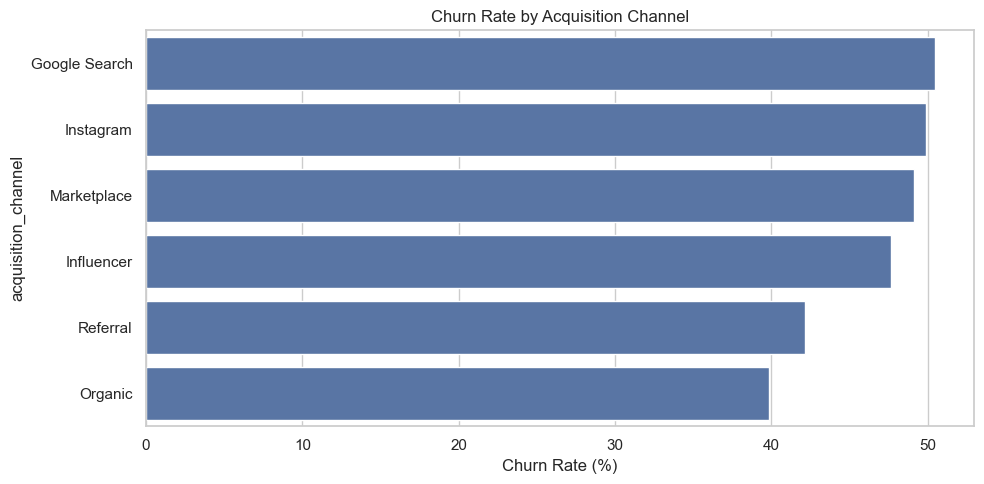

In [127]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=channel_churn.sort_values(
        "churn_rate",
        ascending=False
    ),
    y="acquisition_channel",
    x="churn_rate"
)

plt.title("Churn Rate by Acquisition Channel")
plt.xlabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "churn_by_channel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [128]:
# 7.1.3 Churn by City Tier
city_churn = (
    customer_master
    .groupby("city_tier")["churn_next_60d"]
    .mean()
    .reset_index()
)

city_churn["churn_rate"] = (
    city_churn["churn_next_60d"] * 100
).round(2)

city_churn

,city_tier,churn_next_60d,churn_rate
0,Tier 1,0.473632,47.36
1,Tier 2,0.477011,47.70
2,Tier 3,0.449524,44.95


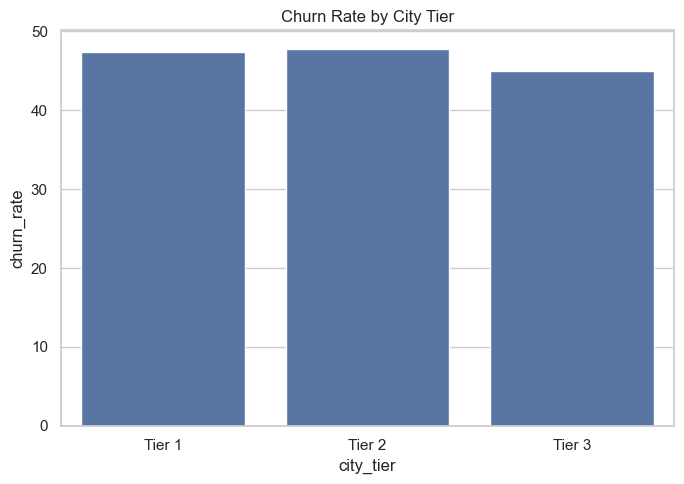

In [129]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=city_churn,
    x="city_tier",
    y="churn_rate"
)

plt.title("Churn Rate by City Tier")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "churn_by_city_tier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [131]:
# 7.1.4 Churn by Loyalty Tier
loyalty_churn = (
    customer_master
    .assign(
        loyalty_tier=lambda x:
        x["loyalty_tier"]
        .fillna("Not Enrolled")
    )
    .groupby("loyalty_tier")["churn_next_60d"]
    .mean()
    .reset_index()
)

loyalty_churn["churn_rate"] = (
    loyalty_churn["churn_next_60d"] * 100
).round(2)

loyalty_churn.sort_values(
    "churn_rate",
    ascending=False
)

,loyalty_tier,churn_next_60d,churn_rate
3,Silver,0.488136,48.81
1,Not Enrolled,0.483405,48.34
0,Gold,0.407524,40.75
2,Platinum,0.371429,37.14


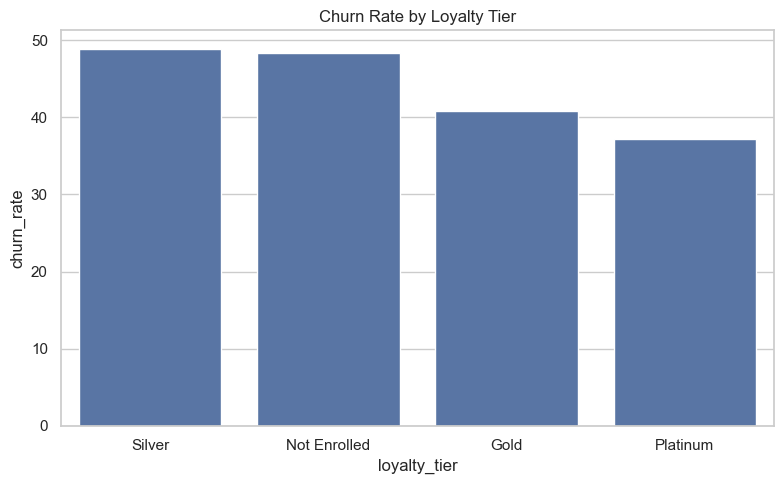

In [132]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=loyalty_churn.sort_values(
        "churn_rate",
        ascending=False
    ),
    x="loyalty_tier",
    y="churn_rate"
)

plt.title("Churn Rate by Loyalty Tier")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "churn_by_loyalty_tier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Churn varies meaningfully across acquisition channels and loyalty tiers. Organic and Referral customers show lower churn rates, while Platinum and Gold members churn less frequently than Silver and non-enrolled customers.
### Business Interpretation

Customer acquisition quality and loyalty program participation appear to influence retention outcomes. These segments should be investigated further as potential churn drivers.

### 7.2 Revenue at risk

In [133]:
# 7.2.1 Revenue by churn Status
revenue_by_churn = (
    customer_master
    .groupby("churn_next_60d")
    .agg(
        customers=("customer_id", "count"),
        total_revenue=("total_spend", "sum"),
        avg_revenue=("total_spend", "mean")
    )
    .reset_index()
)

revenue_by_churn["churn_status"] = (
    revenue_by_churn["churn_next_60d"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

revenue_by_churn[
    [
        "churn_status",
        "customers",
        "total_revenue",
        "avg_revenue"
    ]
]

,churn_status,customers,total_revenue,avg_revenue
0,Retained,1273,3614559.82,2839.402844
1,Churned,1127,2504613.93,2222.372609


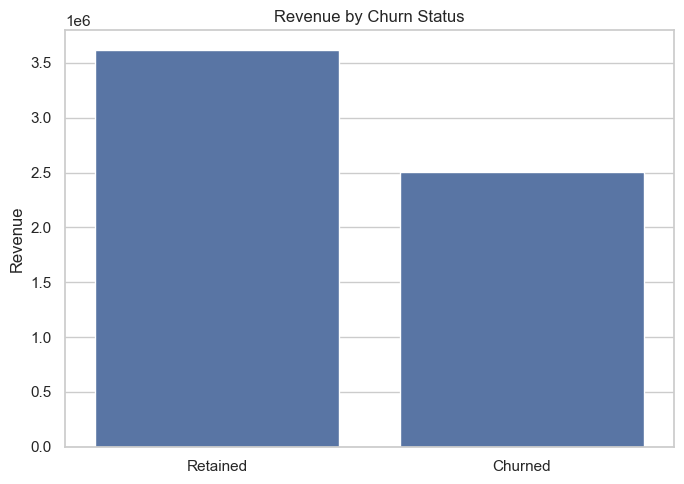

In [134]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=revenue_by_churn,
    x="churn_status",
    y="total_revenue"
)

plt.title("Revenue by Churn Status")
plt.xlabel("")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "revenue_by_churn_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [135]:
# 7.2.2 High Value Customers

customer_master["high_value_customer"] = np.where(
    customer_master["total_spend"]
    >= customer_master["total_spend"].quantile(0.75),
    "High Value",
    "Regular"
)

high_value_summary = (
    customer_master
    .groupby("high_value_customer")
    .agg(
        customers=("customer_id", "count"),
        avg_revenue=("total_spend", "mean")
    )
    .reset_index()
)

high_value_summary

,high_value_customer,customers,avg_revenue
0,High Value,600,5446.168283
1,Regular,1800,1584.151544


In [136]:
# 7.2.3 Revenue Exposure

revenue_exposure = (
    customer_master
    .groupby("churn_next_60d")["total_spend"]
    .sum()
    .reset_index()
)

total_revenue = revenue_exposure["total_spend"].sum()

revenue_exposure["revenue_share_pct"] = (
    revenue_exposure["total_spend"]
    / total_revenue
    * 100
).round(2)

revenue_exposure["churn_status"] = (
    revenue_exposure["churn_next_60d"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

revenue_exposure[
    [
        "churn_status",
        "total_spend",
        "revenue_share_pct"
    ]
]

,churn_status,total_spend,revenue_share_pct
0,Retained,3614559.82,59.07
1,Churned,2504613.93,40.93


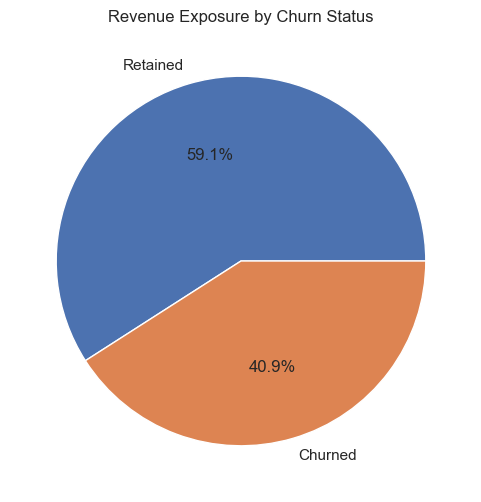

In [137]:
plt.figure(figsize=(6,6))

plt.pie(
    revenue_exposure["total_spend"],
    labels=revenue_exposure["churn_status"],
    autopct="%1.1f%%"
)

plt.title("Revenue Exposure by Churn Status")

plt.savefig(
    CHARTS_DIR / "revenue_exposure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Retained customers generate higher average revenue (₹2,839) than churned customers (₹2,222). Additionally, 40.93% of total revenue comes from customers who eventually churn, indicating substantial revenue exposure.
### Business Interpretation

Churn represents a significant revenue risk for the business. Retention efforts should prioritize high-value customers, as protecting a relatively small segment of customers can preserve a disproportionately large share of revenue.

# 8. Churn-Risk Hypotheses

## 8.1 Hypothesis 1: Loyalty Program Participation

### Hypothesis

Customers enrolled in higher loyalty tiers are less likely to churn.

In [138]:
loyalty_churn = (
    customer_master
    .assign(
        loyalty_tier=lambda x:
        x["loyalty_tier"]
        .fillna("Not Enrolled")
    )
    .groupby("loyalty_tier")["churn_next_60d"]
    .mean()
    .reset_index()
)

loyalty_churn["churn_rate"] = (
    loyalty_churn["churn_next_60d"] * 100
).round(2)

loyalty_churn = loyalty_churn.sort_values(
    "churn_rate",
    ascending=False
)

loyalty_churn

,loyalty_tier,churn_next_60d,churn_rate
3,Silver,0.488136,48.81
1,Not Enrolled,0.483405,48.34
0,Gold,0.407524,40.75
2,Platinum,0.371429,37.14


In [139]:
loyalty_churn.to_csv(
    TABLES_DIR / "hypothesis_1_loyalty_churn.csv",
    index=False
)

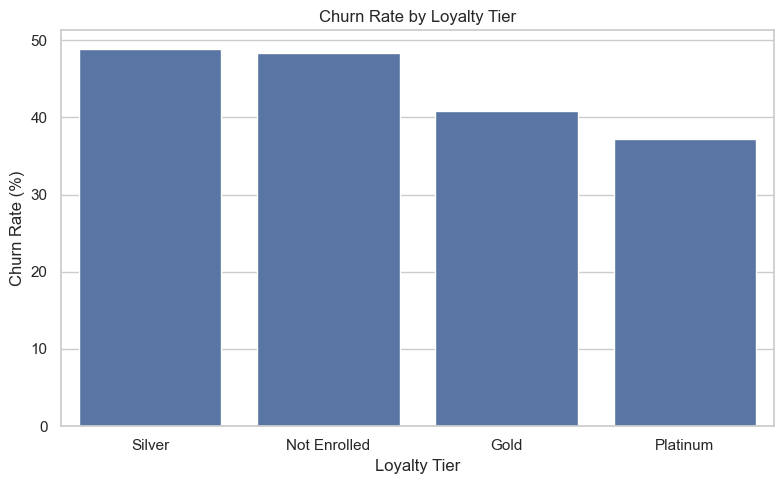

In [140]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=loyalty_churn,
    x="loyalty_tier",
    y="churn_rate"
)

plt.title("Churn Rate by Loyalty Tier")
plt.xlabel("Loyalty Tier")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "churn_by_loyalty_tier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Platinum (37.14%) and Gold (40.75%) customers exhibit lower churn rates than Silver (48.81%) and non-enrolled customers (48.34%).

### Business Implication

Higher loyalty-tier participation appears to be associated with improved customer retention. Expanding loyalty program engagement may help reduce churn.

## 8.2 Hypothesis 2: Acquisition Channel Quality

### Hypothesis

Customer acquisition source influences future churn behaviour.

In [141]:
channel_churn = (
    customer_master
    .groupby("acquisition_channel")["churn_next_60d"]
    .mean()
    .reset_index()
)

channel_churn["churn_rate"] = (
    channel_churn["churn_next_60d"] * 100
).round(2)

channel_churn = channel_churn.sort_values(
    "churn_rate",
    ascending=False
)

channel_churn

,acquisition_channel,churn_next_60d,churn_rate
0,Google Search,0.504292,50.43
2,Instagram,0.499033,49.90
3,Marketplace,0.491228,49.12
1,Influencer,0.476190,47.62
5,Referral,0.421717,42.17
4,Organic,0.398204,39.82


In [142]:
channel_churn.to_csv(
    TABLES_DIR / "hypothesis_2_channel_churn.csv",
    index=False
)

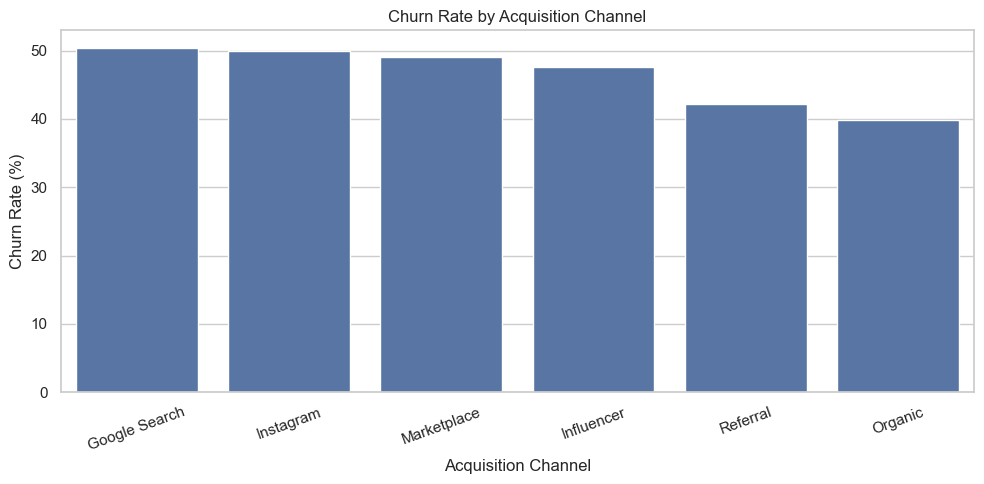

In [143]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=channel_churn,
    x="acquisition_channel",
    y="churn_rate"
)

plt.title("Churn Rate by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "churn_by_acquisition_channel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Customers acquired through Google Search (50.43%) and Instagram (49.90%) exhibit higher churn rates than customers acquired through Organic (39.82%) and Referral channels (42.17%).

### Business Implication

Customer acquisition quality appears to vary across channels. Retention strategies and marketing investments should consider channel-level churn performance when evaluating customer acquisition effectiveness.

## 8.3 Hypothesis 3: Customer Inactivity

### Hypothesis

Customers with prolonged inactivity are significantly more likely to churn.

In [144]:
engagement_churn = (
    customer_master
    .groupby(
        pd.cut(
            customer_master["last_visit_days_ago"],
            bins=[-1, 7, 30, 60],
            labels=[
                "Recent",
                "Moderately Inactive",
                "Highly Inactive"
            ]
        ),
        observed=False
    )["churn_next_60d"]
    .mean()
    .reset_index()
)

engagement_churn["churn_rate"] = (
    engagement_churn["churn_next_60d"] * 100
).round(2)

engagement_churn

,last_visit_days_ago,churn_next_60d,churn_rate
0,Recent,0.187120,18.71
1,Moderately Inactive,0.500000,50.00
2,Highly Inactive,0.883576,88.36


In [145]:
engagement_churn.to_csv(
    TABLES_DIR / "hypothesis_3_inactivity_churn.csv",
    index=False
)

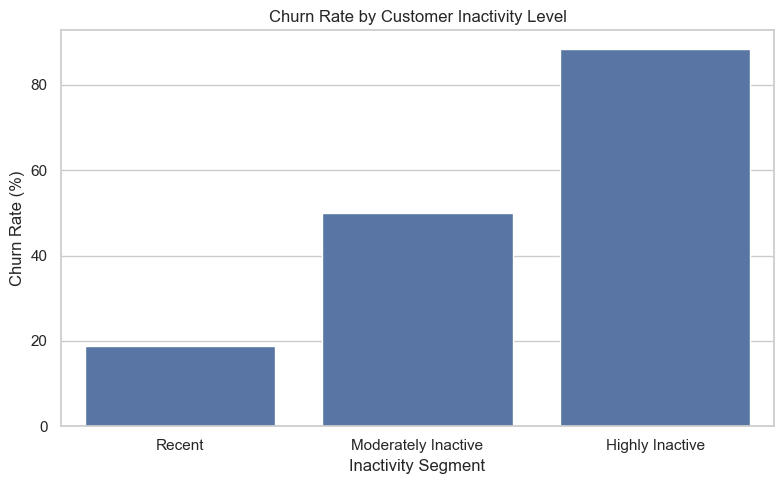

In [146]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=engagement_churn,
    x="last_visit_days_ago",
    y="churn_rate"
)

plt.title("Churn Rate by Customer Inactivity Level")
plt.xlabel("Inactivity Segment")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "churn_by_inactivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Churn rises from 18.71% among recently active customers to 88.36% among highly inactive customers.

### Business Implication

Customer inactivity is one of the strongest early warning indicators of churn.

## 8.4 Hypothesis 4: Support Interaction Volume

### Hypothesis

Customers with frequent support interactions are more likely to churn.

In [147]:
ticket_churn = (
    customer_master
    .assign(
        ticket_segment=pd.cut(
            customer_master["ticket_count"].fillna(0),
            bins=[-1, 0, 2, 100],
            labels=[
                "No Tickets",
                "1-2 Tickets",
                "3+ Tickets"
            ]
        )
    )
    .groupby(
        "ticket_segment",
        observed=False
    )["churn_next_60d"]
    .mean()
    .reset_index()
)

ticket_churn["churn_rate"] = (
    ticket_churn["churn_next_60d"] * 100
).round(2)

ticket_churn

,ticket_segment,churn_next_60d,churn_rate
0,No Tickets,0.471813,47.18
1,1-2 Tickets,0.484018,48.40
2,3+ Tickets,0.348684,34.87


In [148]:
ticket_churn.to_csv(
    TABLES_DIR / "hypothesis_4_ticket_volume_churn.csv",
    index=False
)

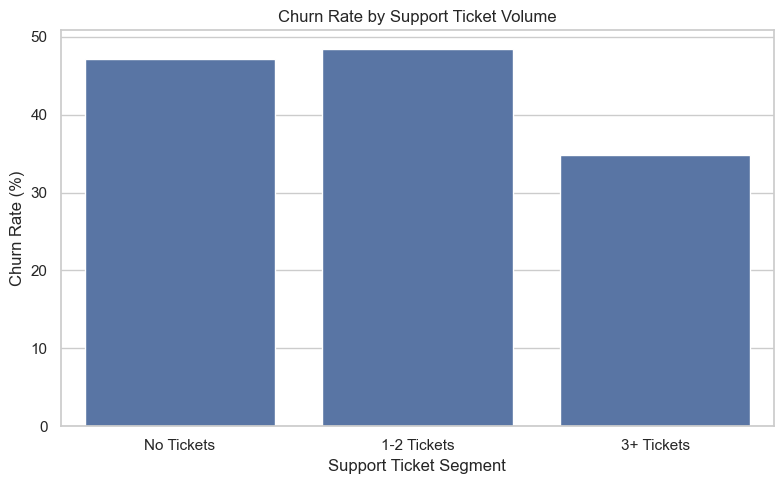

In [149]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=ticket_churn,
    x="ticket_segment",
    y="churn_rate"
)

plt.title("Churn Rate by Support Ticket Volume")
plt.xlabel("Support Ticket Segment")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "churn_by_ticket_volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Customers with three or more support interactions exhibit a lower churn rate (34.87%) than customers with no tickets (47.18%) or one to two tickets (48.40%).

### Business Implication

Support engagement does not appear to increase churn risk in this dataset. Instead, frequent interactions may reflect successful issue resolution and continued customer engagement.

## 8.5 Hypothesis 5: Campaign Engagement

### Hypothesis

Customers who engage with marketing campaigns are less likely to churn.

In [150]:
campaign_churn = (
    customer_master
    .assign(
        campaign_engaged=np.where(
            customer_master["campaign_clicks_30d"] > 0,
            "Engaged",
            "Not Engaged"
        )
    )
    .groupby(
        "campaign_engaged",
        observed=False
    )["churn_next_60d"]
    .mean()
    .reset_index()
)

campaign_churn["churn_rate"] = (
    campaign_churn["churn_next_60d"] * 100
).round(2)

campaign_churn

,campaign_engaged,churn_next_60d,churn_rate
0,Engaged,0.423156,42.32
1,Not Engaged,0.501404,50.14


In [151]:
campaign_churn.to_csv(
    TABLES_DIR / "hypothesis_5_campaign_churn.csv",
    index=False
)

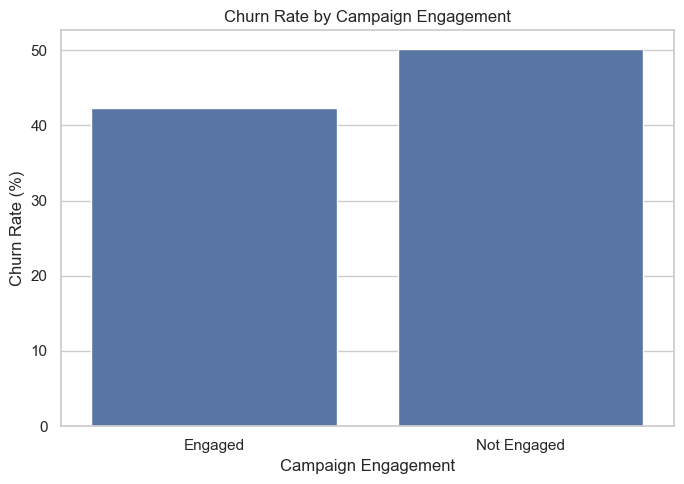

In [152]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=campaign_churn,
    x="campaign_engaged",
    y="churn_rate"
)

plt.title("Churn Rate by Campaign Engagement")
plt.xlabel("Campaign Engagement")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "churn_by_campaign_engagement.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [153]:
campaign_segment_size = (
    customer_master
    .assign(
        campaign_engaged=np.where(
            customer_master["campaign_clicks_30d"] > 0,
            "Engaged",
            "Not Engaged"
        )
    )
    ["campaign_engaged"]
    .value_counts()
    .reset_index()
)

campaign_segment_size.columns = [
    "Campaign Segment",
    "Customer Count"
]

campaign_segment_size

,Campaign Segment,Customer Count
0,Not Engaged,1424
1,Engaged,976


### Interpretation

Campaign-engaged customers exhibit lower churn rates (42.32%) than non-engaged customers (50.14%).

### Business Implication

Improving campaign relevance and engagement may reduce churn.

## 8.6 Hypothesis 6: High-Value Customer Risk

### Hypothesis

High-value customers are less likely to churn than regular customers.

In [154]:
value_churn = (
    customer_master
    .groupby(
        "high_value_customer",
        observed=False
    )["churn_next_60d"]
    .mean()
    .reset_index()
)

value_churn["churn_rate"] = (
    value_churn["churn_next_60d"] * 100
).round(2)

value_churn

,high_value_customer,churn_next_60d,churn_rate
0,High Value,0.351667,35.17
1,Regular,0.508889,50.89


In [155]:
value_churn.to_csv(
    TABLES_DIR / "hypothesis_6_high_value_churn.csv",
    index=False
)

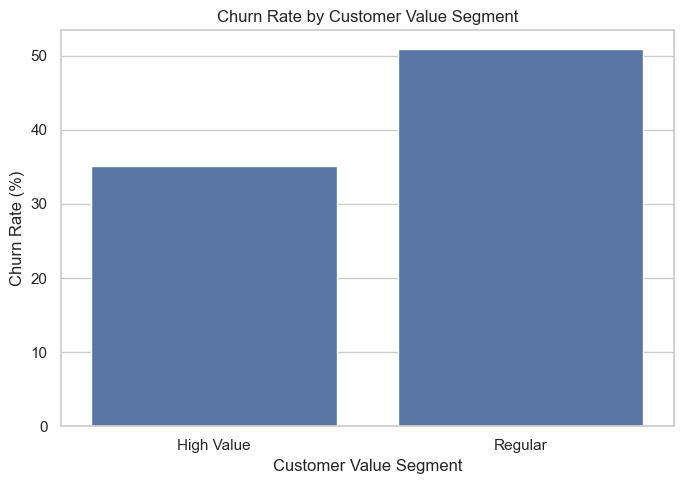

In [156]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=value_churn,
    x="high_value_customer",
    y="churn_rate"
)

plt.title("Churn Rate by Customer Value Segment")
plt.xlabel("Customer Value Segment")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "churn_by_customer_value.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [157]:
value_segment_revenue = (
    customer_master
    .groupby(
        "high_value_customer",
        observed=False
    )
    .agg(
        customers=("customer_id", "count"),
        total_revenue=("total_spend", "sum"),
        avg_revenue=("total_spend", "mean")
    )
    .reset_index()
)

value_segment_revenue["avg_revenue"] = (
    value_segment_revenue["avg_revenue"]
    .round(2)
)

value_segment_revenue["total_revenue"] = (
    value_segment_revenue["total_revenue"]
    .round(2)
)

value_segment_revenue

,high_value_customer,customers,total_revenue,avg_revenue
0,High Value,600,3267700.97,5446.17
1,Regular,1800,2851472.78,1584.15


### Interpretation

High-value customers churn at a substantially lower rate (35.17%) than regular customers (50.89%). This suggests that customers with stronger purchasing relationships are more likely to remain active.

### Business Implication

Although high-value customers represent a smaller customer segment, they contribute a disproportionate share of revenue. Protecting these customers should be a key retention priority due to their business impact.

## Hypothesis Summary

In [158]:
hypothesis_summary = pd.DataFrame({
    "Hypothesis": [
        "Loyalty Program Participation",
        "Acquisition Channel Quality",
        "Customer Inactivity",
        "Support Engagement",
        "Campaign Engagement",
        "High-Value Customer Risk"
    ],
    "Evidence Strength": [
        "Strong",
        "Strong",
        "Very Strong",
        "Moderate",
        "Strong",
        "Very Strong"
    ]
})

hypothesis_summary

,Hypothesis,Evidence Strength
0,Loyalty Program Participation,Strong
1,Acquisition Channel Quality,Strong
2,Customer Inactivity,Very Strong
3,Support Engagement,Moderate
4,Campaign Engagement,Strong
5,High-Value Customer Risk,Very Strong


In [159]:
hypothesis_summary.to_csv(
    TABLES_DIR / "hypothesis_summary.csv",
    index=False
)

### Observation

Six evidence-based churn-risk hypotheses were identified. Customer inactivity and customer value emerged as the strongest predictors of churn behaviour, while loyalty participation, acquisition channel, campaign engagement, and support engagement also demonstrated meaningful relationships with retention outcomes.

### Business Interpretation

The analysis suggests that retention efforts should prioritize inactive customers, high-value customers, and customers with low campaign engagement. These segments represent the most actionable opportunities for reducing churn and protecting future revenue.

# 9. Priority Retention Cohorts

The following customer cohorts were identified as potential retention priorities based on behavioural, engagement, and transaction patterns observed during the analysis.

In [160]:
# 9.1 High Inactivity Customers
high_inactivity = customer_master[
    customer_master["last_visit_days_ago"] > 30
]

high_inactivity_count = len(high_inactivity)

pd.DataFrame({
    "Cohort": ["High Inactivity Customers"],
    "Customer Count": [high_inactivity_count]
})

,Cohort,Customer Count
0,High Inactivity Customers,481


In [161]:
# 9.2 low Purchase Frequency Customers
low_frequency = customer_master[
    customer_master["total_orders"] <= 1
]

low_frequency_count = len(low_frequency)

pd.DataFrame({
    "Cohort": ["Low Purchase Frequency Customers"],
    "Customer Count": [low_frequency_count]
})

,Cohort,Customer Count
0,Low Purchase Frequency Customers,696


In [162]:
# 9.3 Low Campaign Engagement Customers
low_campaign = customer_master[
    customer_master["campaign_clicks_30d"] == 0
]

low_campaign_count = len(low_campaign)

pd.DataFrame({
    "Cohort": ["Low Campaign Engagement Customers"],
    "Customer Count": [low_campaign_count]
})

,Cohort,Customer Count
0,Low Campaign Engagement Customers,1424


In [163]:
# 9.4 High Return Rate Customers
high_returns = customer_master[
    customer_master["return_rate"] > 0.20
]

high_returns_count = len(high_returns)

pd.DataFrame({
    "Cohort": ["High Return Rate Customers"],
    "Customer Count": [high_returns_count]
})

,Cohort,Customer Count
0,High Return Rate Customers,269


In [164]:
# 9.5 Segment sizing Table
retention_cohorts = pd.DataFrame({
    "Retention Cohort": [
        "High Inactivity Customers",
        "Low Purchase Frequency Customers",
        "Low Campaign Engagement Customers",
        "High Return Rate Customers"
    ],
    "Customer Count": [
        high_inactivity_count,
        low_frequency_count,
        low_campaign_count,
        high_returns_count
    ]
})

retention_cohorts.sort_values(
    "Customer Count",
    ascending=False
)

,Retention Cohort,Customer Count
2,Low Campaign Engagement Customers,1424
1,Low Purchase Frequency Customers,696
0,High Inactivity Customers,481
3,High Return Rate Customers,269


In [165]:
retention_cohorts.to_csv(
    TABLES_DIR / "priority_retention_cohorts.csv",
    index=False
)

### Observation

Four priority retention cohorts were identified. Low campaign engagement customers represent the largest at-risk segment (1,424 customers), followed by low purchase frequency customers (696 customers), high inactivity customers (481 customers), and high return rate customers (269 customers).
### Business Interpretation

Retention efforts should initially focus on low campaign engagement and low purchase frequency customers due to their large population size. High inactivity customers represent a smaller but potentially higher-risk segment requiring proactive re-engagement strategies.

# 10. Executive Findings

## Top Churn Drivers

1. Customer inactivity was the strongest churn signal, with churn increasing from 18.71% among recently active customers to 88.36% among highly inactive customers.
2. Loyalty participation was associated with improved retention, particularly among Gold and Platinum members.
3. Campaign-engaged customers churned less frequently than non-engaged customers.
4. Customer acquisition channel influenced retention outcomes.
5. High-value customers exhibited substantially lower churn rates than regular customers.

## Revenue Impact

- Total revenue analysed: ₹6.12 million
- Revenue associated with churned customers: ₹2.50 million
- Revenue exposure from churn: 40.93%
- Top 10% of customers contributed 27.64% of total revenue

## Customer Segments at Risk

| Segment | Customers |
|----------|----------:|
| Low Campaign Engagement | 1,424 |
| Low Purchase Frequency | 696 |
| High Inactivity | 481 |
| High Return Rate | 269 |

## Recommended Focus Areas

1. Reactivate inactive customers before disengagement becomes permanent.
2. Improve campaign targeting and engagement among non-responsive customers.
3. Expand loyalty program participation.
4. Protect high-value customers through personalized retention initiatives.
5. Monitor acquisition channels with elevated churn rates.

# 11. Analysis Limitations

## Snapshot Limitations

The analysis is based on a single customer snapshot and may not capture long-term behavioural changes.

## Correlation vs Causation

Observed relationships identify associations with churn but do not prove causal effects.

## Missing Attributes

Potentially relevant variables such as competitor activity, pricing changes, and customer satisfaction surveys were not available.

## Future Work

Future phases will focus on predictive modelling, retention segmentation, and deployment of a churn-scoring system.

# 12. Final Conclusion

This analysis identified several customer behaviours associated with future churn risk. Customer inactivity emerged as the strongest indicator, followed by loyalty participation, campaign engagement, acquisition channel quality, and customer value.

Approximately 41% of total revenue is associated with customers who eventually churn, highlighting the business importance of proactive retention efforts. The identified retention cohorts and churn-risk hypotheses provide a strong foundation for customer segmentation, retention strategy design, and predictive churn modelling in subsequent project phases.